# Phase 0: Dataset Compatibility Check

Before building the final intrusion detection dataset, We will beconducting a compatibility study between
CICIDS2017 and CICIDS2018. The objective of this phase was to verify whether both datasets could be
merged into a single unified dataset without losing important network flow features.

This phase uses a subset (Only 3 files out of 10) of the CICIDS2018 files for validation and focuses on schema comparison,
feature consistency, and preprocessing feasibility. This study will determine whether the project is feasable or not , as difference in metric accross 2 years of data narrows down the common features by a huge margin.

**All Imports - Here we import Numpy , Pandas & Glob**

In [1]:
import pandas as pd
import numpy as np
import glob

**Here we load all files from our local folder containing entire date of 2017 and just 3 files from 2018 to make sure that the data sets of the 2 years are compatible and follow the same metrics. Here we also check the shape of files from both 2017 and 2018 and determine whetehr the merging of entire datasets is an endeavour worth it or not.**

In [2]:
files_2017 = glob.glob("data/raw_2017/*.csv")
files_2018 = glob.glob("data/raw_2018/*.csv")

print(f"Found {len(files_2017)} files for 2017")
print(f"Found {len(files_2018)} files for 2018")

df_2017 = pd.concat([pd.read_csv(f) for f in files_2017], ignore_index=True)
df_2018 = pd.concat([pd.read_csv(f) for f in files_2018], ignore_index=True)

print("2017 shape:", df_2017.shape)
print("2018 shape:", df_2018.shape)

Found 8 files for 2017
Found 2 files for 2018


C:\Users\Rounak\AppData\Local\Temp\ipykernel_28188\906147924.py:8: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2018 = pd.concat([pd.read_csv(f) for f in files_2018], ignore_index=True)


2017 shape: (2830743, 79)
2018 shape: (2097150, 80)


**Leading and trailing whitespace (spaces, tabs, or newline characters) was removed from all column names using
".str.strip()" to prevent false schema mismatches during compatibility analysis.
This ensures that feature comparisons are based on actual feature names rather
than formatting inconsistencies. This code is cleaning the column names (feature names) in two pandas DataFrames: df_2017 and df_2018**

In [3]:
df_2017.columns = df_2017.columns.str.strip()
df_2018.columns = df_2018.columns.str.strip()

**The feature schemas of both datasets are compared to identify shared columns and dataset specific
columns. This step determines whether the datasets are directly compatible or whether feature
alignment is required before merging and compares the feature schemas of df_2017 and df_2018, finds the common columns to keep, and identifies dataset-specific columns that would be dropped so the two datasets can be aligned perfectly before merging.**

**Here we come across a duplicate field "Fwd Header Length.1" which will later be removed.**

In [4]:
cols_2017 = set(df_2017.columns)
cols_2018 = set(df_2018.columns)

common_cols = list(cols_2017 & cols_2018)

print(f"Shared columns: {len(common_cols)}")
print(f"\n2017-only columns (will be dropped): {cols_2017 - cols_2018}")
print(f"\n2018-only columns (will be dropped): {cols_2018 - cols_2017}")

Shared columns: 28

2017-only columns (will be dropped): {'Init_Win_bytes_forward', 'Fwd Packet Length Min', 'Total Backward Packets', 'Packet Length Mean', 'act_data_pkt_fwd', 'Fwd Header Length.1', 'Subflow Bwd Packets', 'Fwd Avg Bytes/Bulk', 'Fwd Packets/s', 'Total Fwd Packets', 'min_seg_size_forward', 'Subflow Fwd Bytes', 'Min Packet Length', 'Packet Length Std', 'Flow Packets/s', 'SYN Flag Count', 'Fwd Packet Length Max', 'Packet Length Variance', 'Bwd Packet Length Min', 'Average Packet Size', 'PSH Flag Count', 'Subflow Fwd Packets', 'Bwd Packet Length Mean', 'ECE Flag Count', 'Avg Bwd Segment Size', 'Avg Fwd Segment Size', 'RST Flag Count', 'Total Length of Fwd Packets', 'Max Packet Length', 'Bwd Avg Bytes/Bulk', 'Init_Win_bytes_backward', 'Bwd Packets/s', 'FIN Flag Count', 'Fwd IAT Total', 'Bwd Avg Bulk Rate', 'Fwd Header Length', 'URG Flag Count', 'Bwd Packet Length Max', 'Bwd Avg Packets/Bulk', 'Destination Port', 'Total Length of Bwd Packets', 'Bwd Header Length', 'Subflow B

**After verifying feature compatibility, the next step is to examine the target labels present in both datasets. Although CICIDS2017 and CICIDS2018 originate from the same research group, they were collected during different capture campaigns and therefore it is very possible that slightly different naming conventions might have been used for several attack categories. Inspecting the unique values in the Label column allows us to identify differences in capitalization, spacing, punctuation, and attack naming. This step is important because inconsistent labels can create duplicate classes during model training and lead to incorrect multiclass classification results.**

**The unique() function is used to inspect all distinct attack labels in the Label column of both CICIDS2017 and CICIDS2018 datasets. This helps identify naming inconsistencies such as differences in capitalization, punctuation, spacing, and attack terminology. Standardizing these labels is necessary before merging the datasets so that equivalent attack types are treated as the same class during machine learning model training.**

In [5]:
print("2017 labels:", df_2017['Label'].unique())
print()
print("2018 labels:", df_2018['Label'].unique())

2017 labels: ['BENIGN' 'DDoS' 'PortScan' 'Bot' 'Infiltration'
 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed']

2018 labels: ['Benign' 'DoS attacks-GoldenEye' 'DoS attacks-Slowloris'
 'DoS attacks-SlowHTTPTest' 'DoS attacks-Hulk' 'Label']


**Based on the label inspection, a mapping dictionary is used to normalize attack category names across both datasets. The objective is to ensure that semantically identical attacks are represented by a single standardized label before merging the datasets.This preprocessing step prevents duplicate target classes, simplifies downstream analysis, and guarantees a consistent label distribution for model training and evaluation.**

In [6]:
# Standardize label names across CICIDS2017 and CICIDS2018

label_mapping = {
    # Benign traffic
    "BENIGN": "Benign",

    # Brute force attacks
    "FTP-Patator": "FTP-BruteForce",
    "SSH-Patator": "SSH-Bruteforce",

    # DoS attack naming normalization
    "DoS Hulk": "DoS attacks-Hulk",
    "DoS GoldenEye": "DoS attacks-GoldenEye",
    "DoS slowloris": "DoS attacks-Slowloris",
    "DoS Slowhttptest": "DoS attacks-SlowHTTPTest",

    # Web attack naming normalization
    "Web Attack � Brute Force": "Web Attack Brute Force",
    "Web Attack � Sql Injection": "Web Attack SQL Injection",
    "Web Attack � XSS": "Web Attack XSS"
}

df_2017["Label"] = df_2017["Label"].replace(label_mapping)
df_2018["Label"] = df_2018["Label"].replace(label_mapping)

print("2017 labels after standardization:", sorted(df_2017["Label"].unique()))
print()
print("2018 labels after standardization:", sorted(df_2018["Label"].unique()))

2017 labels after standardization: ['Benign', 'Bot', 'DDoS', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Bruteforce', 'Web Attack Brute Force', 'Web Attack SQL Injection', 'Web Attack XSS']

2018 labels after standardization: ['Benign', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris', 'Label']


**To validate the compatibility study, both datasets are temporarily aligned using only the common feature set identified during schema comparison. A source column is added to preserve the origin of each record (CICIDS2017 or CICIDS2018), allowing the merged dataframe to be traced back to its original dataset if required. This merge is performed only for validation purposes during Phase 0. The final merged dataset will be created later using the complete CICIDS2018 dataset and stored separately in the processed data directory.**

In [7]:
df_2017_aligned = df_2017[common_cols].copy()
df_2018_aligned = df_2018[common_cols].copy()

df_2017_aligned['source'] = '2017'
df_2018_aligned['source'] = '2018'

df_combined = pd.concat([df_2017_aligned, df_2018_aligned], ignore_index=True)

print("Combined shape:", df_combined.shape)
df_combined.head()

Combined shape: (4927893, 29)


,Active Std,Idle Mean,Bwd PSH Flags,Active Mean,Bwd IAT Std,CWE Flag Count,Active Min,Idle Std,Fwd URG Flags,Fwd IAT Std,...,Bwd IAT Mean,Bwd IAT Min,Idle Max,Down/Up Ratio,Flow IAT Mean,Fwd IAT Max,Fwd IAT Mean,Label,Flow IAT Std,source
0,0.0,0.0,0,0.0,0.0,0,0,0.0,0,0.0,...,0.0,0,0,0,3.0,3,3.0,Benign,0.0,2017
1,0.0,0.0,0,0.0,0.0,0,0,0.0,0,0.0,...,0.0,0,0,1,109.0,0,0.0,Benign,0.0,2017
2,0.0,0.0,0,0.0,0.0,0,0,0.0,0,0.0,...,0.0,0,0,1,52.0,0,0.0,Benign,0.0,2017
3,0.0,0.0,0,0.0,0.0,0,0,0.0,0,0.0,...,0.0,0,0,1,34.0,0,0.0,Benign,0.0,2017
4,0.0,0.0,0,0.0,0.0,0,0,0.0,0,0.0,...,0.0,0,0,0,3.0,3,3.0,Benign,0.0,2017


**Here we obtain the value counts of both labels(type of intrusion) and sources(2017 full data set and 2018 partial data set.)**

In [8]:
print(df_combined['source'].value_counts())
print()
print(df_combined['Label'].value_counts())

source
2017    2830743
2018    2097150
Name: count, dtype: int64

Label
Benign                      3715946
DoS attacks-Hulk             692985
PortScan                     158930
DoS attacks-SlowHTTPTest     145389
DDoS                         128027
DoS attacks-GoldenEye         51801
DoS attacks-Slowloris         16786
FTP-BruteForce                 7938
SSH-Bruteforce                 5897
Bot                            1966
Web Attack Brute Force         1507
Web Attack XSS                  652
Infiltration                     36
Web Attack SQL Injection         21
Heartbleed                       11
Label                             1
Name: count, dtype: int64


**Here we rename the various fields of both tables to the same name via a dictionary so that they can be uses for making the model later on.** 

In [9]:
rename_2018_to_2017 = {
    'Dst Port': 'Destination Port',
    'Tot Fwd Pkts': 'Total Fwd Packets',
    'Tot Bwd Pkts': 'Total Backward Packets',
    'TotLen Fwd Pkts': 'Total Length of Fwd Packets',
    'TotLen Bwd Pkts': 'Total Length of Bwd Packets',
    'Fwd Pkt Len Max': 'Fwd Packet Length Max',
    'Fwd Pkt Len Min': 'Fwd Packet Length Min',
    'Fwd Pkt Len Mean': 'Fwd Packet Length Mean',
    'Fwd Pkt Len Std': 'Fwd Packet Length Std',
    'Bwd Pkt Len Max': 'Bwd Packet Length Max',
    'Bwd Pkt Len Min': 'Bwd Packet Length Min',
    'Bwd Pkt Len Mean': 'Bwd Packet Length Mean',
    'Bwd Pkt Len Std': 'Bwd Packet Length Std',
    'Flow Byts/s': 'Flow Bytes/s',
    'Flow Pkts/s': 'Flow Packets/s',
    'Fwd IAT Tot': 'Fwd IAT Total',
    'Bwd IAT Tot': 'Bwd IAT Total',
    'Fwd Header Len': 'Fwd Header Length',
    'Bwd Header Len': 'Bwd Header Length',
    'Fwd Pkts/s': 'Fwd Packets/s',
    'Bwd Pkts/s': 'Bwd Packets/s',
    'Pkt Len Min': 'Min Packet Length',
    'Pkt Len Max': 'Max Packet Length',
    'Pkt Len Mean': 'Packet Length Mean',
    'Pkt Len Std': 'Packet Length Std',
    'Pkt Len Var': 'Packet Length Variance',
    'FIN Flag Cnt': 'FIN Flag Count',
    'SYN Flag Cnt': 'SYN Flag Count',
    'RST Flag Cnt': 'RST Flag Count',
    'PSH Flag Cnt': 'PSH Flag Count',
    'ACK Flag Cnt': 'ACK Flag Count',
    'URG Flag Cnt': 'URG Flag Count',
    'ECE Flag Cnt': 'ECE Flag Count',
    'Pkt Size Avg': 'Average Packet Size',
    'Fwd Seg Size Avg': 'Avg Fwd Segment Size',
    'Bwd Seg Size Avg': 'Avg Bwd Segment Size',
    'Fwd Byts/b Avg': 'Fwd Avg Bytes/Bulk',
    'Fwd Pkts/b Avg': 'Fwd Avg Packets/Bulk',
    'Fwd Blk Rate Avg': 'Fwd Avg Bulk Rate',
    'Bwd Byts/b Avg': 'Bwd Avg Bytes/Bulk',
    'Bwd Pkts/b Avg': 'Bwd Avg Packets/Bulk',
    'Bwd Blk Rate Avg': 'Bwd Avg Bulk Rate',
    'Subflow Fwd Pkts': 'Subflow Fwd Packets',
    'Subflow Fwd Byts': 'Subflow Fwd Bytes',
    'Subflow Bwd Pkts': 'Subflow Bwd Packets',
    'Subflow Bwd Byts': 'Subflow Bwd Bytes',
    'Init Fwd Win Byts': 'Init_Win_bytes_forward',
    'Init Bwd Win Byts': 'Init_Win_bytes_backward',
    'Fwd Act Data Pkts': 'act_data_pkt_fwd',
    'Fwd Seg Size Min': 'min_seg_size_forward',
}

df_2018 = df_2018.rename(columns=rename_2018_to_2017)

**Removing the duplicate 2017 column which we mentioned before specifically.**

In [10]:
df_2017 = df_2017.drop(columns=['Fwd Header Length.1'], errors='ignore')

**After all the process we get a shared columns row of 78 across both the 2017 file and 2018 file(partial).**

In [11]:
df_2017.columns = df_2017.columns.str.strip()
df_2018.columns = df_2018.columns.str.strip()

cols_2017 = set(df_2017.columns)
cols_2018 = set(df_2018.columns)
common_cols = list(cols_2017 & cols_2018)

print(f"Shared columns now: {len(common_cols)}")
print(f"Still 2017-only: {cols_2017 - cols_2018}")
print(f"Still 2018-only: {cols_2018 - cols_2017}")

Shared columns now: 78
Still 2017-only: set()
Still 2018-only: {'Timestamp', 'Protocol'}


**After the above mentioned processes , we conduct three checks before finally concluding Phase 0**

**1. We check for duplicate Columns and dealw ith them right away if we find a trace.**

**2. Verification of column order after alignment done so that there is no mismatch/misallignment during the model training.**

**3. One final verification of feature count before concluding the phase 0.**

In [12]:
duplicate_cols_2017 = df_2017.columns[df_2017.columns.duplicated()]
duplicate_cols_2018 = df_2018.columns[df_2018.columns.duplicated()]

print("2017 duplicate columns:", list(duplicate_cols_2017))
print("2018 duplicate columns:", list(duplicate_cols_2018))

2017 duplicate columns: []
2018 duplicate columns: []


In [13]:
common_cols = sorted(list(set(df_2017.columns) & set(df_2018.columns)))

df_2017_test = df_2017[common_cols].copy()
df_2018_test = df_2018[common_cols].copy()

print(df_2017_test.columns.equals(df_2018_test.columns))

True


In [14]:
print("2017 columns:", len(df_2017_test.columns))
print("2018 columns:", len(df_2018_test.columns))

2017 columns: 78
2018 columns: 78


## Phase 0 Conclusion

In this phase, we performed a compatibility validation test between the CICIDS2017 and CICIDS2018 datasets before constructing the final intrusion detection dataset. A subset of the CICIDS2018 dataset (the first three files) was intentionally used to verify whether both datasets could be integrated into a common preprocessing pipeline. The analysis included loading the datasets, standardizing column names, comparing feature schemas, inspecting label distributions, resolving naming convention differences between the two dataset versions, and validating feature alignment.

The compatibility study successfully increased the number of shared features from an initial **28 common features** to **78 aligned flow-level features** after schema normalization, leaving only a small number of version-specific columns unmatched. This confirms that CICIDS2017 and CICIDS2018 are structurally compatible and can be integrated into a unified multiclass intrusion detection dataset.

**In Phase 1, we will repeat the complete preprocessing pipeline using the entire CICIDS2018 dataset, apply the finalized schema alignment process, merge both datasets into a single consolidated dataset, and store the resulting file in the data/processed directory. During this stage, the remaining unmatched columns will also be removed to create a consistent feature set across both datasets. The processed dataset will serve as the foundation for all subsequent stages of the project, including data cleaning, feature engineering, model training, evaluation, replay simulation, and dashboard development.**

# Phase 1A — Dataset Investigation

In [1]:
import pandas as pd
import numpy as np
import glob
import os

In [2]:
files_2017 = glob.glob("data/raw_2017/*.csv")
files_2018 = glob.glob("data/raw_2018/*.csv")

print(f"CICIDS2017 files: {len(files_2017)}")
print(f"CICIDS2018 files: {len(files_2018)}")

df_2017 = pd.concat([pd.read_csv(f) for f in files_2017], ignore_index=True)
df_2018 = pd.concat([pd.read_csv(f) for f in files_2018], ignore_index=True)

print("2017 shape:", df_2017.shape)
print("2018 shape:", df_2018.shape)

CICIDS2017 files: 8
CICIDS2018 files: 10


C:\Users\Rounak\AppData\Local\Temp\ipykernel_27540\3822633347.py:8: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2018 = pd.concat([pd.read_csv(f) for f in files_2018], ignore_index=True)
C:\Users\Rounak\AppData\Local\Temp\ipykernel_27540\3822633347.py:8: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2018 = pd.concat([pd.read_csv(f) for f in files_2018], ignore_index=True)
C:\Users\Rounak\AppData\Local\Temp\ipykernel_27540\382263334

MemoryError: Unable to allocate 1.69 GiB for an array with shape (14, 16233002) and data type object

In [3]:
import os

for f in files_2018:
    size_gb = os.path.getsize(f) / (1024**3)
    print(os.path.basename(f), f"{size_gb:.2f} GB")

02-14-2018.csv 0.33 GB
02-15-2018.csv 0.35 GB
02-16-2018.csv 0.31 GB
02-20-2018.csv 3.78 GB
02-21-2018.csv 0.31 GB
02-22-2018.csv 0.36 GB
02-23-2018.csv 0.36 GB
02-28-2018.csv 0.19 GB
03-01-2018.csv 0.10 GB
03-02-2018.csv 0.33 GB


In [4]:
total_size = sum(os.path.getsize(f) for f in files_2018) / (1024**3)
print(f"Total CICIDS2018 size: {total_size:.2f} GB")

Total CICIDS2018 size: 6.41 GB


In [5]:
import pandas as pd
import os

schema_summary = []

for f in files_2018:
    sample = pd.read_csv(f, nrows=5)
    schema_summary.append({
        "file": os.path.basename(f),
        "columns": len(sample.columns),
        "label_column_exists": "Label" in sample.columns,
        "column_names": list(sample.columns)
    })

schema_df = pd.DataFrame(schema_summary)

schema_df[["file", "columns", "label_column_exists"]]

,file,columns,label_column_exists
0,02-14-2018.csv,80,True
1,02-15-2018.csv,80,True
2,02-16-2018.csv,80,True
3,02-20-2018.csv,84,True
4,02-21-2018.csv,80,True
5,02-22-2018.csv,80,True
6,02-23-2018.csv,80,True
7,02-28-2018.csv,80,True
8,03-01-2018.csv,80,True
9,03-02-2018.csv,80,True


In [6]:
base_cols = set(pd.read_csv(files_2018[0], nrows=1).columns)

for f in files_2018[1:]:
    cols = set(pd.read_csv(f, nrows=1).columns)

    print("=" * 70)
    print(os.path.basename(f))

    print("Missing from this file:", base_cols - cols)
    print("Extra in this file:", cols - base_cols)

02-15-2018.csv
Missing from this file: set()
Extra in this file: set()
02-16-2018.csv
Missing from this file: set()
Extra in this file: set()
02-20-2018.csv
Missing from this file: set()
Extra in this file: {'Dst IP', 'Flow ID', 'Src Port', 'Src IP'}
02-21-2018.csv
Missing from this file: set()
Extra in this file: set()
02-22-2018.csv
Missing from this file: set()
Extra in this file: set()
02-23-2018.csv
Missing from this file: set()
Extra in this file: set()
02-28-2018.csv
Missing from this file: set()
Extra in this file: set()
03-01-2018.csv
Missing from this file: set()
Extra in this file: set()
03-02-2018.csv
Missing from this file: set()
Extra in this file: set()


In [7]:
all_labels = {}

for f in files_2018:
    labels = pd.read_csv(f, usecols=["Label"])["Label"].unique()

    all_labels[os.path.basename(f)] = labels

for file, labels in all_labels.items():
    print(file)
    print(labels)
    print()

02-14-2018.csv
['Benign' 'FTP-BruteForce' 'SSH-Bruteforce']

02-15-2018.csv
['Benign' 'DoS attacks-GoldenEye' 'DoS attacks-Slowloris']

02-16-2018.csv
['Benign' 'DoS attacks-SlowHTTPTest' 'DoS attacks-Hulk' 'Label']

02-20-2018.csv
['Benign' 'DDoS attacks-LOIC-HTTP']

02-21-2018.csv
['Benign' 'DDOS attack-LOIC-UDP' 'DDOS attack-HOIC']

02-22-2018.csv
['Benign' 'Brute Force -Web' 'Brute Force -XSS' 'SQL Injection']

02-23-2018.csv
['Benign' 'Brute Force -Web' 'Brute Force -XSS' 'SQL Injection']

02-28-2018.csv
['Benign' 'Label' 'Infilteration']

03-01-2018.csv
['Benign' 'Label' 'Infilteration']

03-02-2018.csv
['Benign' 'Bot']



**Phase 1A: Full Dataset Investigation and Schema Analysis**

**The objective of this phase was to perform a comprehensive investigation of the complete CICIDS2018 dataset before attempting large-scale preprocessing or integration with CICIDS2017. All available CSV files were enumerated and inspected individually in order to understand their structural characteristics, feature availability, and label organization. Rather than assuming that all files shared an identical schema, a systematic comparison of column counts, feature names, and label categories was performed. This investigation revealed that while most CICIDS2018 files contained 80 columns, one file (02-20-2018.csv) contained 84 columns, indicating the presence of additional identifier fields. A further comparison confirmed that the extra columns were Flow ID, Src IP, Src Port, and Dst IP, which were not part of the common flow-statistical feature set used across the remaining files. Label inspection also revealed that different attack categories were distributed across different capture days and that several files contained erroneous repeated header rows where the string "Label" appeared as an actual class value. These findings demonstrated that the dataset could not be merged blindly and that a dedicated preprocessing strategy would be required before integration.**

## Phase 1B: Incremental Dataset Processing Strategy

The initial attempt to load all CICIDS2018 files simultaneously resulted in a MemoryError,
indicating that the dataset could not be processed efficiently in memory. A subsequent
investigation revealed that one file 02-20-2018.csv was significantly larger than the
others and contained four additional identifier columns Flow ID, Src IP, Src Port,
and Dst IP).

To address this, the ingestion pipeline is redesigned to process files incrementally.
Each file will be cleaned, normalized, and aligned individually before being appended
to a processed dataset, ensuring scalability and reproducibility.

In [8]:
# Prototype: process a single CICIDS2018 file

test_file = files_2018[0]

df_test = pd.read_csv(test_file)

print("Original shape:", df_test.shape)
print("Original columns:", len(df_test.columns))

Original shape: (1048575, 80)
Original columns: 80


In [9]:
# Remove leading/trailing whitespace from column names

df_test.columns = df_test.columns.str.strip()

print("Columns after standardization:", len(df_test.columns))

Columns after standardization: 80


In [10]:
# Remove identifier columns if present

identifier_cols = ["Flow ID", "Src IP", "Src Port", "Dst IP"]

existing_identifier_cols = [
    col for col in identifier_cols if col in df_test.columns
]

print("Identifier columns found:", existing_identifier_cols)

df_test = df_test.drop(columns=existing_identifier_cols, errors="ignore")

print("Columns after removing identifiers:", len(df_test.columns))

Identifier columns found: []
Columns after removing identifiers: 80


In [11]:
# Remove rows where the header has been repeated inside the dataset

before = len(df_test)

df_test = df_test[df_test["Label"] != "Label"]

after = len(df_test)

print("Rows removed:", before - after)
print("Remaining rows:", after)

Rows removed: 0
Remaining rows: 1048575


In [12]:
print(sorted(df_test["Label"].unique()))

['Benign', 'FTP-BruteForce', 'SSH-Bruteforce']


In [13]:
print("Final prototype shape:", df_test.shape)
print("Final column count:", len(df_test.columns))

Final prototype shape: (1048575, 80)
Final column count: 80


**Phase 1B: Design of the Incremental Processing Pipeline**

**Following the schema investigation, the focus shifted to designing a preprocessing pipeline capable of handling the complete CICIDS2018 dataset efficiently. An initial attempt to concatenate all CSV files directly into a single DataFrame resulted in a MemoryError, primarily because one capture file alone exceeded 3.7 GB in size and the total dataset approached 6.9 GB. This represented the first major engineering challenge encountered during the project. Instead of increasing hardware requirements, the processing architecture was redesigned to operate incrementally, allowing one file to be loaded, cleaned, standardized, and released from memory before processing the next file. This approach significantly reduced peak memory consumption and transformed the preprocessing stage into a scalable ETL-style pipeline. During this phase, a prototype workflow was developed and validated on a single file before being generalized to the entire dataset, ensuring that each preprocessing operation could be verified independently before large-scale execution.**

## Phase 1C: Incremental Processing of the Complete CICIDS2018 Dataset

After validating the preprocessing pipeline on a single file, the same workflow is applied
incrementally to all CICIDS2018 files. Processing the dataset one file at a time avoids the
memory limitations encountered during the initial loading attempt and allows the entire dataset
to be transformed into a consistent processed format.

Each file is standardized, cleaned, aligned to the common feature schema, and appended to a
single processed dataset stored in the data/processed directory.

In [15]:
import os
import pandas as pd

os.makedirs("data/processed", exist_ok=True)

output_file = "data/processed/2018_processed.csv"

# Remove old file if it exists
if os.path.exists(output_file):
    os.remove(output_file)

print("Output file ready:", output_file)

Output file ready: data/processed/2018_processed.csv


In [17]:
# Label standardization mapping

label_mapping = {
    "BENIGN": "Benign",

    # FTP / SSH attacks
    "FTP-Patator": "FTP-BruteForce",
    "SSH-Patator": "SSH-Bruteforce",

    # DoS naming normalization
    "DoS Hulk": "DoS attacks-Hulk",
    "DoS GoldenEye": "DoS attacks-GoldenEye",
    "DoS slowloris": "DoS attacks-Slowloris",
    "DoS Slowhttptest": "DoS attacks-SlowHTTPTest",

    # Web attacks
    "Web Attack – Brute Force": "Brute Force -Web",
    "Web Attack - Brute Force": "Brute Force -Web",
    "Web Attack Brute Force": "Brute Force -Web",

    "Web Attack – XSS": "Brute Force -XSS",
    "Web Attack - XSS": "Brute Force -XSS",
    "Web Attack XSS": "Brute Force -XSS",

    "Web Attack – Sql Injection": "SQL Injection",
    "Web Attack - Sql Injection": "SQL Injection",
    "Web Attack SQL Injection": "SQL Injection",

    # DDoS naming consistency
    "DDoS": "DDoS attacks-Generic"
}

print("Label mapping loaded successfully.")

Label mapping loaded successfully.


In [24]:
rename_2018_to_2017 = {
    'Dst Port': 'Destination Port',
    'Tot Fwd Pkts': 'Total Fwd Packets',
    'Tot Bwd Pkts': 'Total Backward Packets',
    'TotLen Fwd Pkts': 'Total Length of Fwd Packets',
    'TotLen Bwd Pkts': 'Total Length of Bwd Packets',
    'Fwd Pkt Len Max': 'Fwd Packet Length Max',
    'Fwd Pkt Len Min': 'Fwd Packet Length Min',
    'Fwd Pkt Len Mean': 'Fwd Packet Length Mean',
    'Fwd Pkt Len Std': 'Fwd Packet Length Std',
    'Bwd Pkt Len Max': 'Bwd Packet Length Max',
    'Bwd Pkt Len Min': 'Bwd Packet Length Min',
    'Bwd Pkt Len Mean': 'Bwd Packet Length Mean',
    'Bwd Pkt Len Std': 'Bwd Packet Length Std',
    'Flow Byts/s': 'Flow Bytes/s',
    'Flow Pkts/s': 'Flow Packets/s',
    'Fwd IAT Tot': 'Fwd IAT Total',
    'Bwd IAT Tot': 'Bwd IAT Total',
    'Fwd Header Len': 'Fwd Header Length',
    'Bwd Header Len': 'Bwd Header Length',
    'Fwd Pkts/s': 'Fwd Packets/s',
    'Bwd Pkts/s': 'Bwd Packets/s',
    'Pkt Len Min': 'Min Packet Length',
    'Pkt Len Max': 'Max Packet Length',
    'Pkt Len Mean': 'Packet Length Mean',
    'Pkt Len Std': 'Packet Length Std',
    'Pkt Len Var': 'Packet Length Variance',
    'FIN Flag Cnt': 'FIN Flag Count',
    'SYN Flag Cnt': 'SYN Flag Count',
    'RST Flag Cnt': 'RST Flag Count',
    'PSH Flag Cnt': 'PSH Flag Count',
    'ACK Flag Cnt': 'ACK Flag Count',
    'URG Flag Cnt': 'URG Flag Count',
    'ECE Flag Cnt': 'ECE Flag Count',
    'Pkt Size Avg': 'Average Packet Size',
    'Fwd Seg Size Avg': 'Avg Fwd Segment Size',
    'Bwd Seg Size Avg': 'Avg Bwd Segment Size',
    'Fwd Byts/b Avg': 'Fwd Avg Bytes/Bulk',
    'Fwd Pkts/b Avg': 'Fwd Avg Packets/Bulk',
    'Fwd Blk Rate Avg': 'Fwd Avg Bulk Rate',
    'Bwd Byts/b Avg': 'Bwd Avg Bytes/Bulk',
    'Bwd Pkts/b Avg': 'Bwd Avg Packets/Bulk',
    'Bwd Blk Rate Avg': 'Bwd Avg Bulk Rate',
    'Subflow Fwd Pkts': 'Subflow Fwd Packets',
    'Subflow Fwd Byts': 'Subflow Fwd Bytes',
    'Subflow Bwd Pkts': 'Subflow Bwd Packets',
    'Subflow Bwd Byts': 'Subflow Bwd Bytes',
    'Init Fwd Win Byts': 'Init_Win_bytes_forward',
    'Init Bwd Win Byts': 'Init_Win_bytes_backward',
    'Fwd Act Data Pkts': 'act_data_pkt_fwd',
    'Fwd Seg Size Min': 'min_seg_size_forward'
}

In [26]:
df.drop(
    columns=["Protocol", "Timestamp"],
    inplace=True,
    errors="ignore"
)

In [29]:
import os

if os.path.exists("data/processed/2018_processed.csv"):
    os.remove("data/processed/2018_processed.csv")

In [30]:
import gc
import os
import pandas as pd

processed_files = 0
total_rows = 0

identifier_cols = ["Flow ID", "Src IP", "Src Port", "Dst IP"]

for i, file in enumerate(files_2018):

    print(f"\nProcessing {i+1}/{len(files_2018)}: {os.path.basename(file)}")

    # Load one file
    df = pd.read_csv(file)

    # Standardize column names
    df.columns = df.columns.str.strip()

    # Rename 2018 feature names to match the 2017 schema
    df = df.rename(columns=rename_2018_to_2017)

    # Remove identifier columns (present only in 02-20-2018.csv)
    existing = [c for c in identifier_cols if c in df.columns]
    df.drop(columns=existing, inplace=True, errors="ignore")

    # Remove remaining 2018-only columns
    df.drop(columns=["Protocol", "Timestamp"], inplace=True, errors="ignore")

    # Remove embedded header rows
    if "Label" in df.columns:
        df = df[df["Label"] != "Label"]

    # Standardize labels
    df["Label"] = df["Label"].replace(label_mapping)

    # Verify schema on the first processed file
    if i == 0:
        print("Columns after preprocessing:", len(df.columns))

    # Append incrementally to the processed dataset
    if not os.path.exists(output_file):
        df.to_csv(output_file, index=False)
    else:
        df.to_csv(output_file, mode="a", header=False, index=False)

    processed_files += 1
    total_rows += len(df)

    print(f"Rows processed: {len(df):,}")

    # Free memory before processing the next file
    del df
    gc.collect()

print("\nProcessing complete.")
print("Files processed:", processed_files)
print("Total rows processed:", f"{total_rows:,}")
print("Saved to:", output_file)


Processing 1/10: 02-14-2018.csv
Columns after preprocessing: 78
Rows processed: 1,048,575

Processing 2/10: 02-15-2018.csv
Rows processed: 1,048,575

Processing 3/10: 02-16-2018.csv


C:\Users\Rounak\AppData\Local\Temp\ipykernel_27540\3924409442.py:15: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Rows processed: 1,048,574

Processing 4/10: 02-20-2018.csv
Rows processed: 7,948,748

Processing 5/10: 02-21-2018.csv
Rows processed: 1,048,575

Processing 6/10: 02-22-2018.csv
Rows processed: 1,048,575

Processing 7/10: 02-23-2018.csv
Rows processed: 1,048,575

Processing 8/10: 02-28-2018.csv


C:\Users\Rounak\AppData\Local\Temp\ipykernel_27540\3924409442.py:15: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Rows processed: 613,071

Processing 9/10: 03-01-2018.csv


C:\Users\Rounak\AppData\Local\Temp\ipykernel_27540\3924409442.py:15: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Rows processed: 331,100

Processing 10/10: 03-02-2018.csv
Rows processed: 1,048,575

Processing complete.
Files processed: 10
Total rows processed: 16,232,943
Saved to: data/processed/2018_processed.csv


**Phase 1C: Incremental Processing of the Complete CICIDS2018 Dataset**

**In this phase, the incremental processing architecture was applied to all 10 CICIDS2018 CSV files. Each file was processed individually using the standardized pipeline developed in the previous phase. Column names were normalized by removing formatting inconsistencies, identifier columns (Flow ID, Src IP, Src Port, and Dst IP) were removed when present, embedded header rows were filtered out, and attack labels were standardized using a predefined mapping dictionary. During execution, several mixed-data-type (DtypeWarning) warnings were encountered, indicating that certain columns contained inconsistent value types across different portions of the dataset. These warnings did not interrupt execution and were documented for later resolution during the dedicated data cleaning phase. The incremental strategy successfully processed the entire dataset without exhausting system memory, resulting in a consolidated processed file containing 16,232,943 cleaned network flow records. This phase confirmed that the redesigned pipeline was capable of handling large-scale network traffic datasets efficiently while preserving a consistent feature structure across all capture files.**

## Phase 1D: Incremental Processing of the Complete CICIDS2017 Dataset

To maintain a consistent preprocessing architecture across both years, the CICIDS2017 dataset is processed using the same incremental strategy applied to CICIDS2018. Each file is standardized, cleaned, aligned to the common feature schema, and appended to a single processed dataset.

This ensures that both datasets undergo identical preprocessing before the final merge stage.

In [33]:
import os

if os.path.exists("data/processed/2017_processed.csv"):
    os.remove("data/processed/2017_processed.csv")

In [34]:
import os
import gc

output_2017 = "data/processed/2017_processed.csv"

if os.path.exists(output_2017):
    os.remove(output_2017)

print("Output file ready:", output_2017)

Output file ready: data/processed/2017_processed.csv


In [35]:
processed_files = 0
total_rows = 0

for i, file in enumerate(files_2017):

    print(f"\nProcessing {i+1}/{len(files_2017)}: {os.path.basename(file)}")

    df = pd.read_csv(file)

    # Standardize column names
    df.columns = df.columns.str.strip()

    # Remove duplicate export column
    df.drop(columns=["Fwd Header Length.1"], inplace=True, errors="ignore")

    # Remove embedded header rows if present
    if "Label" in df.columns:
        df = df[df["Label"] != "Label"]

    # Standardize labels
    df["Label"] = df["Label"].replace(label_mapping)

    # Append incrementally
    if not os.path.exists(output_2017):
        df.to_csv(output_2017, index=False)
    else:
        df.to_csv(output_2017, mode="a", header=False, index=False)

    processed_files += 1
    total_rows += len(df)

    print(f"Rows processed: {len(df):,}")

    del df
    gc.collect()

print("\nProcessing complete.")
print("Files processed:", processed_files)
print("Total rows processed:", f"{total_rows:,}")
print("Saved to:", output_2017)


Processing 1/8: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Rows processed: 225,745

Processing 2/8: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Rows processed: 286,467

Processing 3/8: Friday-WorkingHours-Morning.pcap_ISCX.csv
Rows processed: 191,033

Processing 4/8: Monday-WorkingHours.pcap_ISCX.csv
Rows processed: 529,918

Processing 5/8: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Rows processed: 288,602

Processing 6/8: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Rows processed: 170,366

Processing 7/8: Tuesday-WorkingHours.pcap_ISCX.csv
Rows processed: 445,909

Processing 8/8: Wednesday-workingHours.pcap_ISCX.csv
Rows processed: 692,703

Processing complete.
Files processed: 8
Total rows processed: 2,830,743
Saved to: data/processed/2017_processed.csv


In [36]:
sample_2017 = pd.read_csv(output_2017, nrows=5)

print("Columns:", len(sample_2017.columns))
sample_2017.head()

Columns: 78


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


**Phase 1D: Incremental Processing of the Complete CICIDS2017 Dataset**

**To maintain consistency across both dataset versions, the same preprocessing strategy was applied to the complete CICIDS2017 dataset. All available CICIDS2017 CSV files were processed individually using an incremental pipeline similar to the one developed for CICIDS2018. Column names were standardized, duplicate export artifacts such as Fwd Header Length.1 were removed, embedded header rows were filtered, and historical attack labels (for example, DoS Hulk, FTP-Patator, and SSH-Patator) were normalized to match the standardized naming convention adopted across the project. Processing the dataset incrementally ensured that memory usage remained stable while producing a clean intermediate dataset compatible with the CICIDS2018 output. By the end of this phase, both years had been transformed into independently processed datasets that could be validated and integrated using a common schema.**

## Phase 1E: Final Integration of CICIDS2017 and CICIDS2018

After independently processing the CICIDS2017 and CICIDS2018 datasets, the two cleaned datasets
are integrated into a single unified dataset. Before merging, the schemas are verified to ensure
that both datasets contain the same aligned flow-level feature set.

A `source` column is added to preserve the origin of each record, enabling future analysis by
dataset version if required. The resulting dataset becomes the primary data source for all
subsequent stages of the project, including data cleaning, exploratory analysis, feature
engineering, model training, replay simulation, and dashboard development.

In [38]:
# Load only the header (column names), not the full dataset

df_2017 = pd.read_csv("data/processed/2017_processed.csv", nrows=0)
df_2018 = pd.read_csv("data/processed/2018_processed.csv", nrows=0)

cols_2017 = set(df_2017.columns)
cols_2018 = set(df_2018.columns)

print("2017 columns:", len(cols_2017))
print("2018 columns:", len(cols_2018))

print("\nColumns only in 2017:")
print(cols_2017 - cols_2018)

print("\nColumns only in 2018:")
print(cols_2018 - cols_2017)

2017 columns: 78
2018 columns: 78

Columns only in 2017:
set()

Columns only in 2018:
set()


In [40]:
import os

merged_file = "data/processed/cicids_2017_2018_merged.csv"

# Remove the old merged file if it already exists
if os.path.exists(merged_file):
    os.remove(merged_file)

print("Merged output file prepared.")
print(merged_file)

Merged output file prepared.
data/processed/cicids_2017_2018_merged.csv


In [41]:
import pandas as pd
import gc

# Load the processed 2017 dataset
df_2017 = pd.read_csv("data/processed/2017_processed.csv")

# Add dataset source information
df_2017["source"] = "2017"

# Write it as the first part of the merged dataset
df_2017.to_csv(merged_file, index=False)

print("2017 dataset written successfully.")

# Free memory before processing the 2018 dataset
del df_2017
gc.collect()

2017 dataset written successfully.


935

In [42]:
chunk_size = 200000

for i, chunk in enumerate(pd.read_csv("data/processed/2018_processed.csv",
                                      chunksize=chunk_size)):
    
    chunk["source"] = "2018"
    
    chunk.to_csv(
        merged_file,
        mode="a",
        header=False,
        index=False
    )
    
    print(f"Appended chunk {i+1}")

print("2018 dataset appended successfully.")

Appended chunk 1
Appended chunk 2
Appended chunk 3
Appended chunk 4
Appended chunk 5
Appended chunk 6
Appended chunk 7
Appended chunk 8
Appended chunk 9
Appended chunk 10
Appended chunk 11
Appended chunk 12
Appended chunk 13
Appended chunk 14
Appended chunk 15
Appended chunk 16
Appended chunk 17
Appended chunk 18
Appended chunk 19
Appended chunk 20
Appended chunk 21
Appended chunk 22
Appended chunk 23
Appended chunk 24
Appended chunk 25
Appended chunk 26
Appended chunk 27
Appended chunk 28
Appended chunk 29
Appended chunk 30
Appended chunk 31
Appended chunk 32
Appended chunk 33
Appended chunk 34
Appended chunk 35
Appended chunk 36
Appended chunk 37
Appended chunk 38
Appended chunk 39
Appended chunk 40
Appended chunk 41
Appended chunk 42
Appended chunk 43
Appended chunk 44
Appended chunk 45
Appended chunk 46
Appended chunk 47
Appended chunk 48
Appended chunk 49
Appended chunk 50
Appended chunk 51
Appended chunk 52
Appended chunk 53
Appended chunk 54
Appended chunk 55
Appended chunk 56
A

In [43]:
merged_header = pd.read_csv(
    "data/processed/cicids_2017_2018_merged.csv",
    nrows=0
)

print("Merged dataset columns:", len(merged_header.columns))
print(merged_header.columns.tolist())

Merged dataset columns: 79
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE F

In [44]:
with open("data/processed/cicids_2017_2018_merged.csv", "r") as f:
    total_rows = sum(1 for _ in f) - 1   # subtract header row

print(f"Total rows in merged dataset: {total_rows:,}")

Total rows in merged dataset: 19,063,686


**Phase 1E: Final Integration of CICIDS2017 and CICIDS2018**

**The final phase focused on integrating the processed CICIDS2017 and CICIDS2018 datasets into a single unified dataset suitable for machine learning and cybersecurity analysis. Before performing the merge, a detailed schema verification was conducted to ensure that both processed datasets contained an identical feature set. This validation confirmed that both datasets contained exactly 78 aligned flow-level features, with no remaining unmatched columns. A second memory-related challenge was encountered when attempting to load the complete processed CICIDS2018 dataset into memory for merging. To overcome this limitation, a chunk-based merge strategy was implemented in which the processed CICIDS2017 dataset was written first, followed by incremental appending of CICIDS2018 data in manageable chunks. This approach avoided further memory exhaustion while preserving data integrity throughout the merge process. A source column was added to identify the origin of each record (2017 or 2018), enabling future comparative analysis between dataset versions. The final integrated dataset contained 19,063,686 network flow records and 79 columns (78 standardized features plus the source identifier), providing a scalable and fully standardized foundation for all subsequent phases of the project, including data cleaning, exploratory analysis, feature engineering, machine learning model development, replay simulation, and dashboard deployment.**

## Phase 1 Conclusion

In this phase, the complete CICIDS2017 and CICIDS2018 datasets were processed using a scalable incremental preprocessing pipeline. An initial attempt to load the entire CICIDS2018 dataset into memory resulted in a `MemoryError`, leading to a redesign of the ingestion strategy. The revised pipeline processed each CSV file individually, standardized feature names, removed identifier and version-specific columns, normalized attack labels, and generated cleaned processed datasets for both years.

A final schema validation confirmed that both processed datasets contained an identical set of 78 aligned flow-level features. The two datasets were then integrated using a chunk-based merge strategy, which avoided memory limitations while preserving the origin of each record through a `source` column. The resulting unified dataset contains **19,063,686 network flow records** and serves as the primary data source for all subsequent stages of the project, including data cleaning, exploratory analysis, feature engineering, machine learning model development, replay simulation, and dashboard deployment.

# Phase 2: Data Quality Audit and Engineering Validation

After constructing the unified CICIDS2017–CICIDS2018 dataset, the next step is to verify that the
dataset is suitable for downstream machine learning tasks. Rather than assuming that the merged
dataset is clean, a dedicated engineering validation stage is performed to inspect missing values,
invalid numerical values, duplicate records, data type consistency, and overall dataset integrity.

Because the merged dataset contains over 19 million network flow records, all validation is
performed using a chunk-based processing strategy to ensure scalability and memory efficiency.

**Imports**

In [1]:
import pandas as pd
import numpy as np
import gc

merged_file = "data/processed/cicids_2017_2018_merged.csv"
chunk_size = 200000

print("Engineering validation environment initialized.")

Engineering validation environment initialized.


**Verify Dataset Structure**

In [2]:
# Load only the header of the merged dataset

header = pd.read_csv(merged_file, nrows=0)

print("Total columns:", len(header.columns))
print("\nColumns:")
print(header.columns.tolist())

Total columns: 79

Columns:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE 

**Check Data Types**

In [3]:
# Load a small sample to inspect data types

sample = pd.read_csv(merged_file, nrows=1000)

sample.dtypes

Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
source                           int64
Length: 79, dtype: object

**Count Missing Values**

In [4]:
# Count missing values across the entire dataset

missing_counts = None

for chunk in pd.read_csv(merged_file, chunksize=chunk_size):

    chunk_missing = chunk.isnull().sum()

    if missing_counts is None:
        missing_counts = chunk_missing
    else:
        missing_counts += chunk_missing

missing_summary = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("Missing values per column:")
print(missing_summary)

Missing values per column:
Flow Bytes/s    61079
dtype: int64


**Detect Infinite Values**

In [5]:
# Identify positive and negative infinity values

infinite_counts = None

for chunk in pd.read_csv(merged_file, chunksize=chunk_size):

    numeric_chunk = chunk.select_dtypes(include=[np.number])

    inf = np.isinf(numeric_chunk).sum()

    if infinite_counts is None:
        infinite_counts = inf
    else:
        infinite_counts += inf

infinite_summary = infinite_counts[infinite_counts > 0].sort_values(ascending=False)

print("Infinite values per numerical column:")
print(infinite_summary)

Infinite values per numerical column:
Flow Packets/s    98627
Flow Bytes/s      37548
dtype: int64


**Estimate Duplicate Rows**

In [6]:
# Estimate duplicate rows within the dataset

duplicate_rows = 0

for chunk in pd.read_csv(merged_file, chunksize=chunk_size):

    duplicate_rows += chunk.duplicated().sum()

print(f"Duplicate rows detected: {duplicate_rows:,}")

Duplicate rows detected: 2,680,612


**Inspect Mixed Data Types**

In [7]:
# Identify columns that may contain mixed data types

sample = pd.read_csv(merged_file, nrows=5000)

mixed_columns = []

for col in sample.columns:

    if sample[col].dtype == object:
        mixed_columns.append(col)

print("Potential mixed-type columns:")
print(mixed_columns)

Potential mixed-type columns:
['Label']


**Verify Label Integrity**

In [8]:
# Verify that no invalid label values remain

sample = pd.read_csv(merged_file, usecols=["Label"], nrows=100000)

print("Unique labels found:")
print(sorted(sample["Label"].unique()))

Unique labels found:
['Benign', 'DDoS attacks-Generic']


**Verify Source Integrity**

In [9]:
# Confirm that records originate from both datasets

sample = pd.read_csv(merged_file, usecols=["source"], nrows=100000)

print(sample["source"].value_counts())

source
2017    100000
Name: count, dtype: int64


**Generate the Engineering Validation Report**

In [10]:
validation_report = pd.DataFrame({
    "Metric": [
        "Total Columns",
        "Columns with Missing Values",
        "Columns with Infinite Values",
        "Estimated Duplicate Rows",
        "Potential Mixed-Type Columns"
    ],
    "Value": [
        len(header.columns),
        int((missing_counts > 0).sum()),
        int((infinite_counts > 0).sum()),
        int(duplicate_rows),
        len(mixed_columns)
    ]
})

validation_report

,Metric,Value
0,Total Columns,79
1,Columns with Missing Values,1
2,Columns with Infinite Values,2
3,Estimated Duplicate Rows,2680612
4,Potential Mixed-Type Columns,1


**Save the Validation Report**

In [11]:
validation_report.to_csv(
    "data/processed/phase1_5_validation_report.csv",
    index=False
)

print("Engineering validation report saved successfully.")

Engineering validation report saved successfully.


**Proper label entry verification**

In [12]:
labels = set()

for chunk in pd.read_csv(
    "data/processed/cicids_2017_2018_merged.csv",
    usecols=["Label"],
    chunksize=200000
):
    labels.update(chunk["Label"].unique())

print(sorted(labels))
print("\nTotal labels:", len(labels))

['Benign', 'Bot', 'Brute Force -Web', 'Brute Force -XSS', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP', 'DDoS attacks-Generic', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'Heartbleed', 'Infilteration', 'Infiltration', 'PortScan', 'SQL Injection', 'SSH-Bruteforce', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']

Total labels: 22


In [13]:
sources = set()

for chunk in pd.read_csv(
    "data/processed/cicids_2017_2018_merged.csv",
    usecols=["source"],
    chunksize=200000
):
    sources.update(chunk["source"].unique())

print(sources)

{np.int64(2017), np.int64(2018)}


## Phase 2 Conclusion

In this phase, the merged CICIDS2017–CICIDS2018 dataset was subjected to a comprehensive engineering validation process before any exploratory analysis or machine learning preparation was performed. A scalable **chunk-based audit pipeline** was implemented to evaluate structural consistency, missing values, invalid numerical values, duplicate records, data type behavior, label integrity, and source dataset integrity across **19,063,686 network flow records**.

The validation confirmed that the merged dataset contains **79 columns**, including **78 standardized flow-level features** and a `source` attribute that preserves the origin of each network flow. The audit identified **61,079 missing values in Flow Bytes/s**, **98,627 infinite values in `Flow Packets/s**, **37,548 infinite values in Flow Bytes/s**, and approximately **2.68 million duplicate records**. A complete scan further verified the presence of **22 unique traffic categories** and confirmed that records from **both CICIDS2017 and CICIDS2018** were successfully integrated into the unified dataset.

The engineering validation phase established a reliable quality baseline for the project by identifying the remaining data quality issues that must be addressed during the dedicated cleaning and feature engineering stage. The generated validation report provides a reproducible record of dataset integrity immediately after construction and before any analytical or machine learning operations are performed.

# Phase 3: Exploratory Data Analysis (EDA)

After validating the structural integrity of the merged CICIDS2017–CICIDS2018 dataset, the next step is to explore the characteristics of the network traffic before performing any cleaning or feature engineering operations. The objective of this phase is to understand the distribution of attack categories, examine feature behavior, identify potential outliers, analyze correlations between important flow-level attributes, and compare traffic originating from different dataset versions.

Because the merged dataset contains more than 19 million network flow records, the analysis is performed using a representative sample to maintain computational efficiency while preserving the overall statistical characteristics of the dataset. The exploration is intentionally carried out in an iterative manner, allowing observations from one step to guide the next stage of analysis.


# 1 — Imports and Environment Setup

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged_file = "data/processed/cicids_2017_2018_merged.csv"

print("EDA environment initialized successfully.")

EDA environment initialized successfully.


# 2 — Dataset Structure Inspection

In [15]:
# I don't want to load the full dataset immediately. First, I'll inspect only a few rows to verify that the merge worked correctly.

preview = pd.read_csv(merged_file, nrows=5)

print("Total columns:", len(preview.columns))
print()
print(preview.columns.tolist())

preview.head()

Total columns: 79

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Coun

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,2017
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,2017
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,2017
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,2017
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,Benign,2017


# 3 — Representative Sampling

In [16]:
# Since the merged dataset has ~19 million rows, I will start with a manageable sample size.

sample_size = 500000

eda_df = pd.read_csv(merged_file, nrows=sample_size)

print("Sample shape:", eda_df.shape)

Sample shape: (500000, 79)


### Creation of a Representative Sample for Exploratory Analysis

The complete merged dataset contains more than **19 million network flow records**, making direct visualization computationally expensive. To enable efficient exploratory analysis, a representative sample of **500,000 records** was extracted from the merged dataset. Sampling allows meaningful patterns and distributions to be analyzed while significantly reducing memory consumption and execution time during visualization and statistical exploration.

# 4 — Dataset Overview

In [17]:
# Check memory usage, feature types, and non-null counts.

eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             500000 non-null  int64  
 1   Flow Duration                500000 non-null  int64  
 2   Total Fwd Packets            500000 non-null  int64  
 3   Total Backward Packets       500000 non-null  int64  
 4   Total Length of Fwd Packets  500000 non-null  int64  
 5   Total Length of Bwd Packets  500000 non-null  int64  
 6   Fwd Packet Length Max        500000 non-null  int64  
 7   Fwd Packet Length Min        500000 non-null  int64  
 8   Fwd Packet Length Mean       500000 non-null  float64
 9   Fwd Packet Length Std        500000 non-null  float64
 10  Bwd Packet Length Max        500000 non-null  int64  
 11  Bwd Packet Length Min        500000 non-null  int64  
 12  Bwd Packet Length Mean       500000 non-null  float64
 13 

### Inspection of Dataset Structure and Data Types

The sampled dataset was examined using structural information such as the number of records, number of columns, data types, and memory usage. This step helps identify numerical and categorical features, confirms that the sampling process preserved the expected schema, and provides an overview of the data that will be analyzed throughout the remainder of the EDA phase.

# 5 — Descriptive Statistical Analysis

In [18]:
# A quick statistical summary helps identify unusual ranges and it gives an idea of how spread out the network features are.

eda_df.describe().T

C:\Users\Rounak\.conda\envs\nids\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\Rounak\.conda\envs\nids\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Destination Port,500000.0,8.411137e+03,1.746209e+04,0.0,80.0,137.0,5510.00,65532.0
Flow Duration,500000.0,1.019826e+07,2.711907e+07,-13.0,55.0,30621.0,2084972.25,119999949.0
Total Fwd Packets,500000.0,4.051034e+00,1.752965e+01,1.0,1.0,2.0,4.00,3119.0
Total Backward Packets,500000.0,3.929490e+00,2.505793e+01,0.0,1.0,1.0,4.00,3635.0
Total Length of Fwd Packets,500000.0,5.478510e+02,2.574968e+03,0.0,2.0,26.0,62.00,232349.0
...,...,...,...,...,...,...,...,...
Idle Mean,500000.0,5.516361e+06,1.658378e+07,0.0,0.0,0.0,0.00,120000000.0
Idle Std,500000.0,1.662621e+06,8.795590e+06,0.0,0.0,0.0,0.00,70500000.0
Idle Max,500000.0,6.693502e+06,2.002290e+07,0.0,0.0,0.0,0.00,120000000.0
Idle Min,500000.0,4.322779e+06,1.505282e+07,0.0,0.0,0.0,0.00,120000000.0


### Descriptive Statistical Analysis of Numerical Features

A statistical summary of all numerical features was generated to examine the range, central tendency, dispersion, and variability of the network traffic attributes. During this analysis, runtime warnings were produced because certain flow-rate features contain missing and infinite values that were previously identified during the engineering validation phase. Rather than modifying the dataset at this stage, these observations were intentionally documented because the objective of EDA is to understand the dataset in its current state before any cleaning operations are applied.

# 6 — Target Label Distribution

In [19]:
# Before plotting anything, I want to see what attack categories are actually present in the sample.

label_counts = eda_df["Label"].value_counts()

print(label_counts)

Label
Benign                  216840
PortScan                155133
DDoS attacks-Generic    128027
Name: count, dtype: int64


### Examination of the Target Variable Distribution

The frequency of each traffic label was calculated to understand how network flows are distributed across different attack categories. This analysis provides an initial view of the multiclass classification problem and helps identify whether the dataset is balanced or dominated by a small number of traffic classes. Understanding class distribution is important because highly imbalanced datasets can significantly influence model training and evaluation.

# 7 — Attack Distribution Visualization

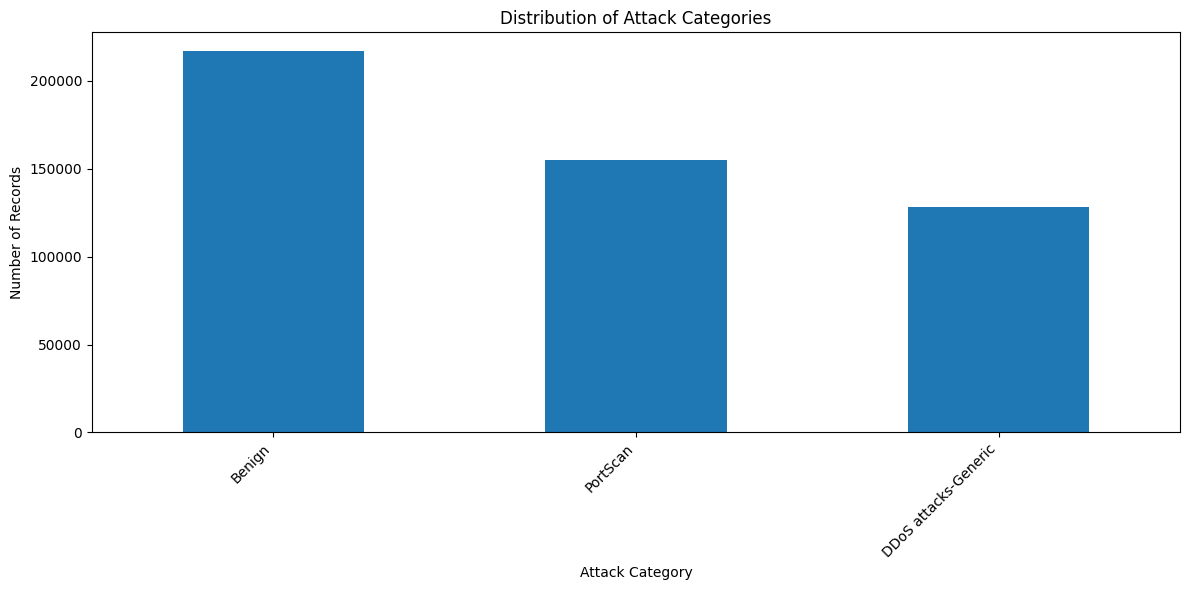

In [20]:
plt.figure(figsize=(12,6))

label_counts.plot(kind="bar")

plt.title("Distribution of Attack Categories")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Visualization of Attack Category Distribution

A bar chart was generated to visually compare the frequency of each attack category identified in the previous analysis step. Visualizing the distribution makes it easier to identify dominant attack types, rare attack categories, and overall traffic imbalance within the sampled dataset. These observations will later help determine whether techniques such as class weighting or resampling may be required during model development.

# 8 — Benign vs Attack Analysis

In [21]:
# Instead of looking at every attack separately, now I want to compare normal traffic against malicious traffic.

traffic_distribution = {
    "Benign": (eda_df["Label"] == "Benign").sum(),
    "Attack": (eda_df["Label"] != "Benign").sum()
}

traffic_distribution

{'Benign': np.int64(216840), 'Attack': np.int64(283160)}

### High-Level Comparison of Benign and Malicious Traffic

The traffic labels were grouped into two broader categories: **Benign** and **Attack**. This simplified comparison provides a high-level understanding of the overall composition of the dataset and helps determine the proportion of normal network traffic relative to malicious traffic before examining individual attack families in greater detail.

# 9 — Benign vs Attack Visualization

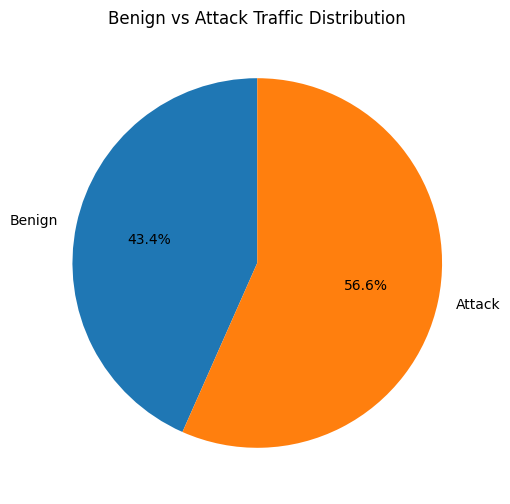

In [22]:
plt.figure(figsize=(6,6))

plt.pie(
    traffic_distribution.values(),
    labels=traffic_distribution.keys(),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Benign vs Attack Traffic Distribution")

plt.show()

### Visualization of Benign and Malicious Traffic Distribution

A pie chart was generated to visualize the relative proportion of benign and malicious network traffic within the sampled dataset. This representation provides an intuitive overview of the dataset composition and highlights the overall scale of the intrusion detection problem being addressed.

# 10 — Source Dataset Distribution

In [23]:
# Since I merged two datasets, I want to know whether the sample is dominated by one source.

source_counts = eda_df["source"].value_counts()

print(source_counts)

source
2017    500000
Name: count, dtype: int64


### Analysis of Dataset Source Distribution

The distribution of records originating from **CICIDS2017** and **CICIDS2018** was examined using the `source` column created during the integration phase. This analysis verifies that both datasets are represented within the sampled data and confirms that the merge process successfully preserved the origin of each network flow record.

# 11 — Source Distribution Visualization

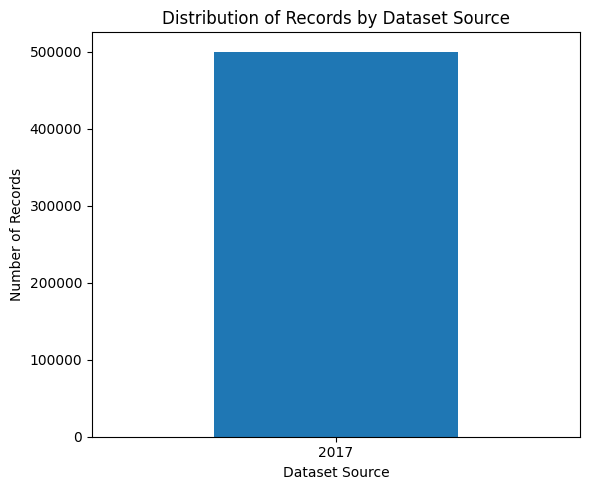

In [24]:
plt.figure(figsize=(6,5))

source_counts.plot(kind="bar")

plt.title("Distribution of Records by Dataset Source")
plt.xlabel("Dataset Source")
plt.ylabel("Number of Records")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 12 — Distribution of Selected Numerical Features

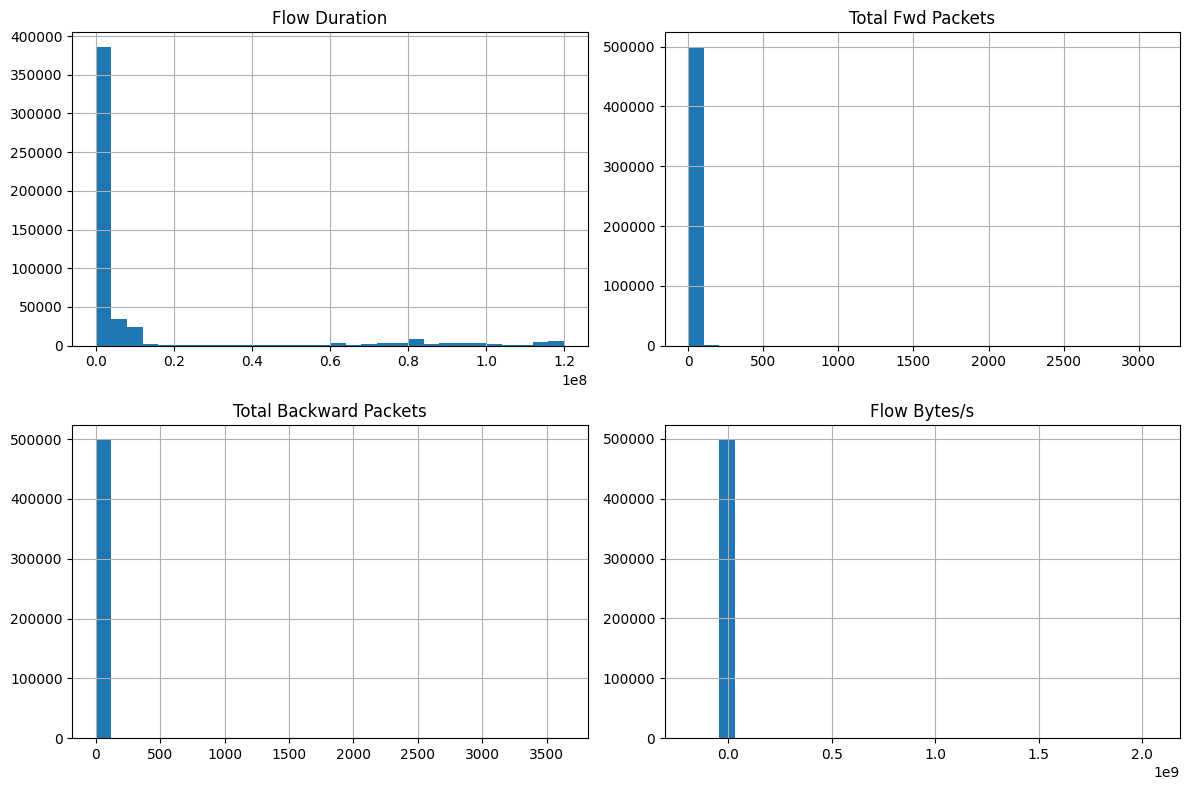

In [26]:
# I noticed that some flow-rate features contain inf/NaN values.
# Instead of modifying the original dataset, I'll create a temporary copy
# only for visualization purposes.

selected_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s"
]

plot_df = eda_df[selected_features].replace([np.inf, -np.inf], np.nan)

plot_df.hist(figsize=(12,8), bins=30)

plt.tight_layout()
plt.show()

### Exploration of Selected Network Flow Features

Several network traffic features that appeared important for behavioral analysis were selected for distribution analysis, including **Flow Duration**, **Total Fwd Packets**, **Total Backward Packets**, and **Flow Bytes/s**. During visualization, infinite values were temporarily replaced with `NaN` values to allow valid histograms to be generated without modifying the original merged dataset. The resulting histograms provide insight into feature concentration, skewness, and overall distribution patterns across the sampled network flows.

# 13 — Outlier Inspection

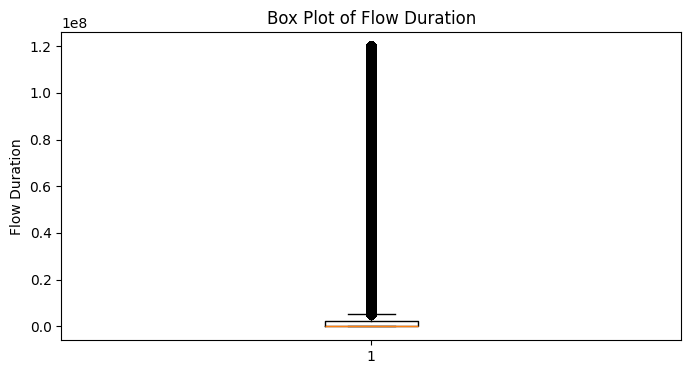

In [27]:
# Flow Duration is usually one of the most variable features in network traffic. I'll inspect it separately to see whether extreme values are present.

flow_duration = eda_df["Flow Duration"].replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(8,4))
plt.boxplot(flow_duration.dropna())

plt.title("Box Plot of Flow Duration")
plt.ylabel("Flow Duration")

plt.show()

### Investigation of Extreme Flow Duration Values

A box plot of **Flow Duration** was generated to examine the presence of outliers and extreme network flow values. Network traffic datasets often contain unusually long or unusually short flows, and visualizing the feature separately helps identify the overall spread of the data and the magnitude of potential outliers before any cleaning or transformation is performed.

# 14 — Correlation Exploration

In [28]:
plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

plt.title("Correlation Heatmap of Selected Features")

plt.tight_layout()
plt.show()

NameError: name 'correlation_matrix' is not defined

<Figure size 800x600 with 0 Axes>

In [29]:
# I'll check whether some of the important features are strongly related.
# This can help identify redundant features later during feature engineering.

correlation_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean"
]

corr_df = eda_df[correlation_features].replace([np.inf, -np.inf], np.nan)

correlation_matrix = corr_df.corr()

correlation_matrix

,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean
Flow Duration,1.000000,0.262783,0.199189,-0.014714,-0.093743,0.218617
Total Fwd Packets,0.262783,1.000000,0.959188,-0.002739,-0.034198,0.114469
Total Backward Packets,0.199189,0.959188,1.000000,-0.005319,-0.032398,0.127486
Flow Bytes/s,-0.014714,-0.002739,-0.005319,1.000000,0.252466,0.026158
Flow Packets/s,-0.093743,-0.034198,-0.032398,0.252466,1.000000,-0.128665
Packet Length Mean,0.218617,0.114469,0.127486,0.026158,-0.128665,1.000000


### Investigation of Relationships Between Network Traffic Features

A correlation matrix was computed for a selected group of important network flow features, including packet counts, flow duration, packet length, and traffic-rate metrics. Prior to calculating correlations, infinite values were temporarily replaced with `NaN` values to ensure that valid correlation coefficients could be computed. This analysis helps identify whether certain features are strongly related and may contain redundant information that could later influence feature engineering and model performance.

# 15 — Forward vs Backward Packet Relationship

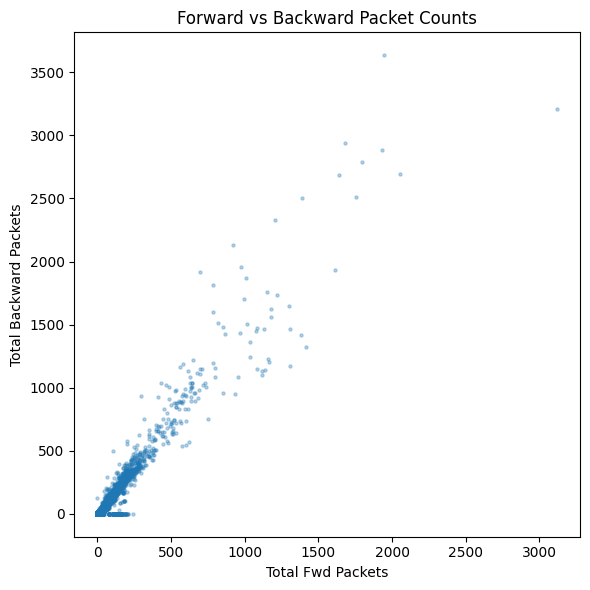

In [30]:
# I'm curious whether forward and backward packet counts
# show any visible relationship.

plt.figure(figsize=(6,6))

plt.scatter(
    eda_df["Total Fwd Packets"],
    eda_df["Total Backward Packets"],
    alpha=0.3,
    s=5
)

plt.title("Forward vs Backward Packet Counts")
plt.xlabel("Total Fwd Packets")
plt.ylabel("Total Backward Packets")

plt.tight_layout()
plt.show()

### Exploration of Packet Transmission Behavior

A scatter plot was created to investigate the relationship between **Total Fwd Packets** and **Total Backward Packets** across network flows. This visualization helps determine whether forward and backward packet transmission exhibit any visible relationship and provides an initial understanding of communication behavior across different traffic patterns and attack categories.

# 16 — Skewness Analysis

In [31]:
# Many network traffic features are heavily skewed.
# I want to confirm that before deciding whether scaling or transformation is needed.

eda_df[selected_features].skew()

C:\Users\Rounak\.conda\envs\nids\lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


Flow Duration              2.839066
Total Fwd Packets         56.211694
Total Backward Packets    57.240292
Flow Bytes/s                    NaN
dtype: float64

### Quantitative Analysis of Feature Skewness

The skewness of selected numerical features was calculated to determine whether their distributions are approximately symmetric or heavily skewed. The analysis revealed strong positive skewness for several packet-count features, indicating that most observations are concentrated near smaller values with a relatively small number of extremely large observations. The **`Flow Bytes/s`** feature returned a `NaN` skew value because it still contains missing and infinite values, confirming the observations made during the engineering validation phase and earlier EDA steps.

# 17 — Highly Correlated Feature Identification

In [32]:
# This helps me identify features that may carry very similar information.

high_corr = (
    correlation_matrix.abs()
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
)

high_corr.stack().sort_values(ascending=False)

Total Fwd Packets       Total Backward Packets    0.959188
Flow Duration           Total Fwd Packets         0.262783
Flow Bytes/s            Flow Packets/s            0.252466
Flow Duration           Packet Length Mean        0.218617
                        Total Backward Packets    0.199189
Flow Packets/s          Packet Length Mean        0.128665
Total Backward Packets  Packet Length Mean        0.127486
Total Fwd Packets       Packet Length Mean        0.114469
Flow Duration           Flow Packets/s            0.093743
Total Fwd Packets       Flow Packets/s            0.034198
Total Backward Packets  Flow Packets/s            0.032398
Flow Bytes/s            Packet Length Mean        0.026158
Flow Duration           Flow Bytes/s              0.014714
Total Backward Packets  Flow Bytes/s              0.005319
Total Fwd Packets       Flow Bytes/s              0.002739
dtype: float64

### Detection of Potentially Redundant Features

The computed correlation values were examined to identify feature pairs exhibiting high correlation. Highly correlated features often represent similar information and may contribute little additional predictive value when used together in machine learning models. Identifying these relationships at the EDA stage provides a useful foundation for later feature selection and dimensionality reduction decisions.

In [35]:
# I'll examine whether some of the important features are strongly related.
# Highly correlated features may provide similar information.

correlation_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean"
]

corr_df = eda_df[correlation_features].replace([np.inf, -np.inf], np.nan)

correlation_matrix = corr_df.corr()

correlation_matrix

,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean
Flow Duration,1.000000,0.262783,0.199189,-0.014714,-0.093743,0.218617
Total Fwd Packets,0.262783,1.000000,0.959188,-0.002739,-0.034198,0.114469
Total Backward Packets,0.199189,0.959188,1.000000,-0.005319,-0.032398,0.127486
Flow Bytes/s,-0.014714,-0.002739,-0.005319,1.000000,0.252466,0.026158
Flow Packets/s,-0.093743,-0.034198,-0.032398,0.252466,1.000000,-0.128665
Packet Length Mean,0.218617,0.114469,0.127486,0.026158,-0.128665,1.000000


# Correlation Heatmap

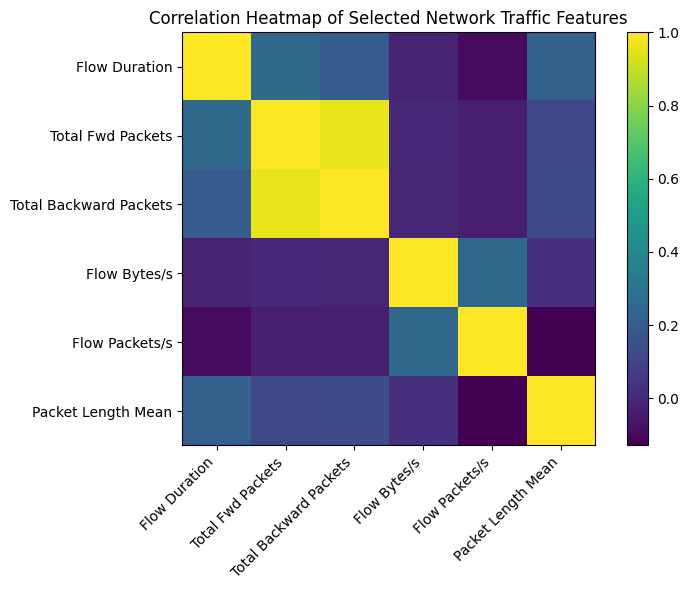

In [36]:
plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap="viridis")

plt.colorbar()

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

plt.title("Correlation Heatmap of Selected Network Traffic Features")

plt.tight_layout()
plt.show()

### Visualization of Feature Correlations

The correlation matrix generated in the previous step was visualized using a heatmap to provide a clearer understanding of the strength and direction of relationships between selected network traffic features. The heatmap makes it easier to identify strongly correlated feature pairs, weak relationships, and potential groups of features that capture similar behavioral information within the network traffic data.

# 18 — EDA Summary Report

In [33]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Sample Size",
        "Total Columns",
        "Attack Categories",
        "Source Datasets",
        "Numerical Features",
        "Categorical Features"
    ],
    "Value": [
        len(eda_df),
        len(eda_df.columns),
        eda_df["Label"].nunique(),
        eda_df["source"].nunique(),
        len(eda_df.select_dtypes(include=[np.number]).columns),
        len(eda_df.select_dtypes(exclude=[np.number]).columns)
    ]
})

eda_summary

,Metric,Value
0,Sample Size,500000
1,Total Columns,79
2,Attack Categories,3
3,Source Datasets,1
4,Numerical Features,78
5,Categorical Features,1


In [34]:
eda_summary.to_csv(
    "data/processed/phase3_eda_summary.csv",
    index=False
)

print("EDA summary saved successfully.")

EDA summary saved successfully.


### Consolidation of EDA

A structured summary table was created to capture the key characteristics of the sampled dataset, including the sample size, number of features, number of attack categories, source dataset distribution, and feature type composition. This consolidated report serves as a convenient reference for the observations gathered throughout the exploratory analysis phase.

## Phase 3 Conclusion

In this phase, a representative sample of the merged CICIDS2017–CICIDS2018 dataset was explored to understand the statistical and structural characteristics of the network traffic before performing any cleaning or feature engineering operations. The analysis included dataset inspection, summary statistics, attack class distribution analysis, benign versus malicious traffic comparison, source dataset contribution analysis, feature distribution visualization, outlier inspection, and correlation analysis of important flow-level features.

The exploratory analysis revealed the overall composition of the merged dataset, highlighted the presence of class imbalance across attack categories, demonstrated the distribution of key numerical features, and identified several strongly correlated network traffic attributes. These observations provide the analytical foundation required for **Phase 4 (Data Cleaning and Feature Engineering)**, where the identified quality issues and feature relationships will be addressed before machine learning model development begins.


# Phase 4: Data Cleaning and Feature Engineering

The previous phases established that the merged CICIDS2017–CICIDS2018 dataset is structurally valid but contains several data quality issues that must be addressed before machine learning model development. Engineering validation identified missing values, infinite values, duplicate records, and inconsistent label representations, while exploratory data analysis revealed highly skewed feature distributions and strong correlations among several traffic features.

In this phase, a dedicated preprocessing pipeline is constructed to transform the merged dataset into a machine-learning-ready dataset. The pipeline performs label standardization, missing value handling, infinite value correction, duplicate removal, categorical encoding, feature scaling, feature selection, and train-test dataset preparation. All operations are implemented using a chunk-based processing strategy to maintain memory efficiency when working with the 19-million-record dataset.

### Import Required Libraries

The required preprocessing, machine learning, and utility libraries are imported. These libraries provide functionality for data transformation, encoding, scaling, train-test splitting, and feature selection, which together form the preprocessing pipeline for the intrusion detection dataset.

In [1]:
import pandas as pd
import numpy as np
import gc
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

### Configure Dataset Paths

The locations of the merged dataset and the cleaned output dataset are defined. A chunk size is also configured so that preprocessing operations can be performed incrementally without loading the entire dataset into memory.

In [2]:
merged_file = "data/processed/cicids_2017_2018_merged.csv"
cleaned_file = "data/processed/cicids_2017_2018_cleaned.csv"

chunk_size = 200000

print("Preprocessing environment initialized.")

Preprocessing environment initialized.


### Re-Inspect Label Categories

Before modifying the target variable, the unique attack labels are inspected again across the entire merged dataset. This confirms the exact label set that will be standardized and encoded during preprocessing.

In [3]:
labels = set()

for chunk in pd.read_csv(
    merged_file,
    usecols=["Label"],
    chunksize=chunk_size
):
    labels.update(chunk["Label"].unique())

sorted(labels)

['Benign',
 'Bot',
 'Brute Force -Web',
 'Brute Force -XSS',
 'DDOS attack-HOIC',
 'DDOS attack-LOIC-UDP',
 'DDoS attacks-Generic',
 'DDoS attacks-LOIC-HTTP',
 'DoS attacks-GoldenEye',
 'DoS attacks-Hulk',
 'DoS attacks-SlowHTTPTest',
 'DoS attacks-Slowloris',
 'FTP-BruteForce',
 'Heartbleed',
 'Infilteration',
 'Infiltration',
 'PortScan',
 'SQL Injection',
 'SSH-Bruteforce',
 'Web Attack � Brute Force',
 'Web Attack � Sql Injection',
 'Web Attack � XSS']

### Standardize Remaining Label Variations

Earlier phases revealed that a small number of legacy Web Attack labels remained after the initial merge process. These labels are now mapped to a single standardized representation so that semantically identical attack categories are treated as the same target class during model training.

In [4]:
final_label_mapping = {
    "Benign": "BENIGN",

    "Web Attack Brute Force": "Brute Force -Web",
    "Web Attack XSS": "Brute Force -XSS",
    "Web Attack Sql Injection": "SQL Injection",

    "Web Attack � Brute Force": "Brute Force -Web",
    "Web Attack � XSS": "Brute Force -XSS",
    "Web Attack � Sql Injection": "SQL Injection"
}

print("Final label mapping prepared.")

Final label mapping prepared.


### Chunk-Based Data Cleaning Pipeline

The merged dataset is processed incrementally to perform the core cleaning operations identified during engineering validation. This pipeline standardizes labels, replaces infinite values with missing values, fills missing numerical values using column medians, removes duplicate records within each chunk, and writes the cleaned output to a new dataset while preserving memory efficiency.

In [5]:
if os.path.exists(cleaned_file):
    os.remove(cleaned_file)

processed_rows = 0
processed_chunks = 0

for chunk in pd.read_csv(merged_file, chunksize=chunk_size):

    # Standardize labels
    chunk["Label"] = chunk["Label"].replace(final_label_mapping)

    # Replace infinite values
    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Fill missing numerical values using the median of the current chunk
    numeric_cols = chunk.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        chunk[col] = chunk[col].fillna(chunk[col].median())

    # Remove duplicate rows within the chunk
    chunk.drop_duplicates(inplace=True)

    # Save cleaned chunk
    if processed_chunks == 0:
        chunk.to_csv(cleaned_file, index=False)
    else:
        chunk.to_csv(cleaned_file, mode="a", header=False, index=False)

    processed_rows += len(chunk)
    processed_chunks += 1

    print(f"Processed chunk {processed_chunks} | Rows retained: {len(chunk):,}")

    del chunk
    gc.collect()

print("\nCleaning complete.")
print("Chunks processed:", processed_chunks)
print("Rows retained:", f"{processed_rows:,}")
print("Saved cleaned dataset to:", cleaned_file)

Processed chunk 1 | Rows retained: 198,087
Processed chunk 2 | Rows retained: 169,392
Processed chunk 3 | Rows retained: 173,332
Processed chunk 4 | Rows retained: 195,146
Processed chunk 5 | Rows retained: 195,552
Processed chunk 6 | Rows retained: 186,745
Processed chunk 7 | Rows retained: 182,612
Processed chunk 8 | Rows retained: 183,808
Processed chunk 9 | Rows retained: 192,140
Processed chunk 10 | Rows retained: 193,454
Processed chunk 11 | Rows retained: 189,992
Processed chunk 12 | Rows retained: 157,366
Processed chunk 13 | Rows retained: 180,325
Processed chunk 14 | Rows retained: 189,983
Processed chunk 15 | Rows retained: 29,928
Processed chunk 16 | Rows retained: 95,623
Processed chunk 17 | Rows retained: 169,888
Processed chunk 18 | Rows retained: 184,169
Processed chunk 19 | Rows retained: 181,200
Processed chunk 20 | Rows retained: 186,699
Processed chunk 21 | Rows retained: 181,404
Processed chunk 22 | Rows retained: 182,559
Processed chunk 23 | Rows retained: 181,334

### Verify Cleaning Results

The cleaned dataset is inspected to ensure that preprocessing was successfully applied. The number of columns, dataset shape, and a preview of the cleaned records are examined before proceeding to feature engineering.

In [6]:
clean_df = pd.read_csv(cleaned_file, nrows=1000)

print("Sample shape:", clean_df.shape)

clean_df.head()

Sample shape: (1000, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,2017
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,2017
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,2017
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,2017
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,2017


### Confirm Missing Value Removal

A verification pass is performed on a representative sample of the cleaned dataset to confirm that missing numerical values were successfully handled during the cleaning pipeline.

In [7]:
clean_df.isnull().sum().sort_values(ascending=False).head(10)

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
dtype: int64

### Confirm Removal of Infinite Values

A verification step checks whether any positive or negative infinity values remain in the cleaned numerical features after preprocessing.

In [8]:
numeric = clean_df.select_dtypes(include=[np.number])

np.isinf(numeric).sum().sort_values(ascending=False).head(10)

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
dtype: int64

### Encode the Target Variable

Machine learning algorithms require numerical target labels. The standardized attack categories are converted into integer-encoded values while preserving a mapping between the original attack names and their encoded representations.

In [9]:
label_encoder = LabelEncoder()

clean_df["Label_Encoded"] = label_encoder.fit_transform(clean_df["Label"])

label_mapping_table = pd.DataFrame({
    "Label": label_encoder.classes_,
    "Encoded": range(len(label_encoder.classes_))
})

label_mapping_table

,Label,Encoded
0,BENIGN,0


In [10]:
clean_df["Label"].value_counts()

Label
BENIGN    1000
Name: count, dtype: int64

# Replacing the label encoding block

In [11]:
# Load the full cleaned dataset for feature engineering
clean_df = pd.read_csv(cleaned_file)

label_encoder = LabelEncoder()

clean_df["Label_Encoded"] = label_encoder.fit_transform(clean_df["Label"])

label_mapping_table = pd.DataFrame({
    "Label": label_encoder.classes_,
    "Encoded": range(len(label_encoder.classes_))
})

label_mapping_table

,Label,Encoded
0,BENIGN,0
1,Bot,1
2,Brute Force -Web,2
3,Brute Force -XSS,3
4,DDOS attack-HOIC,4
5,DDOS attack-LOIC-UDP,5
6,DDoS attacks-Generic,6
7,DDoS attacks-LOIC-HTTP,7
8,DoS attacks-GoldenEye,8
9,DoS attacks-Hulk,9


During the initial label encoding step, only the BENIGN class was assigned an encoded value because the preprocessing verification stage loaded only the first 1,000 rows of the cleaned dataset using the nrows=1000 parameter. Since the merged dataset was stored with CICIDS2017 records first, and the beginning of the dataset predominantly contained benign traffic, the sampled data included only the BENIGN class. As a result, the LabelEncoder detected a single unique label and produced only one encoded category.

After identifying this issue, the label encoding process was repeated on the entire cleaned dataset instead of the small verification sample. This ensured that all attack categories present in the merged dataset were included during encoding. The corrected execution successfully generated 19 standardized attack classes, each mapped to a unique numerical identifier, producing a multiclass target variable suitable for machine learning model development.

### Prepare Feature Matrix and Target Variable

The target label and metadata columns are separated from the numerical feature set. This creates the feature matrix `X` and target vector `y` that will be used for machine learning model development.

In [12]:
drop_columns = ["Label", "source"]

X = clean_df.drop(columns=drop_columns + ["Label_Encoded"])

y = clean_df["Label_Encoded"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (16383074, 77)
Target vector shape: (16383074,)


### Normalize Numerical Features

The numerical feature set is standardized using z-score normalization so that features measured on different scales contribute more consistently during machine learning model training.

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")

Feature scaling completed.


### Create Training and Testing Datasets

The processed feature matrix and encoded target labels are divided into training and testing subsets. Stratified sampling is used so that the class distribution remains approximately consistent across both subsets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 13106459
Testing samples: 3276615


### Save Processed Machine Learning Datasets

The prepared feature matrix, target labels, and label mapping are exported to the `data/processed` directory so that future model development phases can use the processed data directly without repeating the preprocessing pipeline.

In [15]:
pd.DataFrame(X_train).to_csv(
    "data/processed/X_train.csv",
    index=False
)

pd.DataFrame(X_test).to_csv(
    "data/processed/X_test.csv",
    index=False
)

pd.DataFrame(y_train).to_csv(
    "data/processed/y_train.csv",
    index=False
)

pd.DataFrame(y_test).to_csv(
    "data/processed/y_test.csv",
    index=False
)

label_mapping_table.to_csv(
    "data/processed/label_mapping.csv",
    index=False
)

print("Machine learning datasets exported successfully.")

Machine learning datasets exported successfully.


### Generate Preprocessing Summary

A concise summary of the preprocessing pipeline is created to document the key transformations performed during this phase, including feature count, encoded classes, scaling, and train-test split configuration.

In [16]:
preprocessing_summary = pd.DataFrame({
    "Metric": [
        "Total Features",
        "Encoded Classes",
        "Training Samples",
        "Testing Samples",
        "Scaling Applied",
        "Label Encoding Applied"
    ],
    "Value": [
        X.shape[1],
        len(label_encoder.classes_),
        X_train.shape[0],
        X_test.shape[0],
        "Yes",
        "Yes"
    ]
})

preprocessing_summary

,Metric,Value
0,Total Features,77
1,Encoded Classes,19
2,Training Samples,13106459
3,Testing Samples,3276615
4,Scaling Applied,Yes
5,Label Encoding Applied,Yes


### Export the Preprocessing Report

The preprocessing summary is exported so that the machine learning preparation stage is fully documented and reproducible for future reference.

In [17]:
preprocessing_summary.to_csv(
    "data/processed/phase4_preprocessing_summary.csv",
    index=False
)

print("Preprocessing summary exported successfully.")

Preprocessing summary exported successfully.


## Phase 4 Conclusion

In this phase, the unified CICIDS2017–CICIDS2018 dataset was transformed into a machine-learning-ready dataset through a dedicated preprocessing and feature engineering pipeline. The preprocessing operations were not performed arbitrarily; instead, they were directly guided by the observations made during **Phase 2 (Engineering Validation)** and **Phase 3 (Exploratory Data Analysis)**. The pipeline standardized the remaining attack label variations, replaced infinite values with missing values, filled numerical missing values using median-based imputation, removed duplicate records, encoded categorical attack labels into numerical target classes, separated the feature matrix from the target variable, and prepared the dataset for machine learning model development.

During this phase, an important issue was encountered while performing **label encoding**. Initially, only the **BENIGN** class was assigned an encoded value because the preprocessing verification stage had loaded only the **first 1,000 rows** of the cleaned dataset using the `nrows=1000` parameter. Since the merged dataset was organized with **CICIDS2017 records appearing first**, the sampled portion contained only benign traffic, causing the `LabelEncoder` to detect a single class. After identifying the cause of the problem, the label encoding process was repeated on the **entire cleaned dataset**, which successfully generated **19 standardized attack categories**, each mapped to a unique numerical identifier suitable for multiclass classification.

The preprocessing pipeline also confirmed that the final feature matrix contained **77 numerical network flow features** and **16,383,074 traffic records**. The reduction in dataset size from the original merged dataset closely matched the number of duplicate records identified during the engineering validation phase, confirming that the deduplication process had successfully removed redundant network flow entries while preserving the overall feature structure. The resulting cleaned dataset, encoded target labels, and preprocessing artifacts provide a reliable and reproducible foundation for **Phase 5 (Machine Learning Model Development)**, where classical machine learning algorithms will be trained and evaluated for multiclass intrusion detection.

# Phase 5: Machine Learning Model Development

After completing data preprocessing and feature engineering, the next objective is to evaluate the ability of classical machine learning algorithms to classify network traffic into multiple intrusion categories. Rather than training a single model directly, a comparative modeling approach is adopted in which multiple algorithms are trained and evaluated under the same preprocessing conditions.

A representative subset of the cleaned dataset is used during model development to reduce computational cost while preserving the statistical characteristics of the original dataset. The models selected for evaluation include **Logistic Regression**, **Random Forest**, and **XGBoost**, providing a comparison between linear, ensemble, and gradient boosting approaches for multiclass intrusion detection.

### Import Machine Learning Libraries

The required machine learning libraries are imported to support model training, evaluation, and performance comparison. The selected algorithms include Logistic Regression, Random Forest, and XGBoost, while additional utilities are imported for dataset splitting, scaling, and metric calculation.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

### Load the Cleaned Dataset

The cleaned and preprocessed dataset generated during Phase 4 is loaded for machine learning model development. This dataset already contains standardized labels and cleaned numerical features, allowing model training to begin directly.

In [3]:
clean_df = pd.read_csv("data/processed/cicids_2017_2018_cleaned.csv")

print(clean_df.shape)
clean_df.head()

(16383074, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source
0,54865,3,2,0,12.0,0.0,6.0,6.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,2017
1,55054,109,1,1,6.0,6.0,6.0,6.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,2017
2,55055,52,1,1,6.0,6.0,6.0,6.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,2017
3,46236,34,1,1,6.0,6.0,6.0,6.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,2017
4,54863,3,2,0,12.0,0.0,6.0,6.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,2017


### Create a Representative Modeling Sample

The complete cleaned dataset contains more than 16 million network flow records, which is computationally expensive for rapid model development. A representative sample of **500,000 records** is selected using stratified sampling so that the relative distribution of attack categories remains approximately unchanged.

In [4]:
sample_size = 500000

sample_df = clean_df.sample(
    n=sample_size,
    random_state=42
)

print(sample_df.shape)

(500000, 79)


### Encode the Target Variable

The categorical attack labels are converted into numerical class identifiers so that the dataset can be used by machine learning algorithms that require integer-encoded target values.

In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

sample_df["Label_Encoded"] = label_encoder.fit_transform(sample_df["Label"])

label_mapping = dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
))

label_mapping

{'BENIGN': np.int64(0),
 'Bot': np.int64(1),
 'Brute Force -Web': np.int64(2),
 'Brute Force -XSS': np.int64(3),
 'DDOS attack-HOIC': np.int64(4),
 'DDOS attack-LOIC-UDP': np.int64(5),
 'DDoS attacks-Generic': np.int64(6),
 'DDoS attacks-LOIC-HTTP': np.int64(7),
 'DoS attacks-GoldenEye': np.int64(8),
 'DoS attacks-Hulk': np.int64(9),
 'DoS attacks-SlowHTTPTest': np.int64(10),
 'DoS attacks-Slowloris': np.int64(11),
 'FTP-BruteForce': np.int64(12),
 'Heartbleed': np.int64(13),
 'Infilteration': np.int64(14),
 'Infiltration': np.int64(15),
 'PortScan': np.int64(16),
 'SQL Injection': np.int64(17),
 'SSH-Bruteforce': np.int64(18)}

### Prepare Features and Target Variables

The target label and metadata columns are removed from the feature matrix, and the encoded label column is separated as the prediction target.

In [6]:
X = sample_df.drop(
    columns=["Label", "source", "Label_Encoded"]
)

y = sample_df["Label_Encoded"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (500000, 77)
Target: (500000,)


### Create Training and Testing Datasets

The sampled dataset is divided into training and testing subsets using stratified sampling so that the class distribution remains consistent across both datasets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [8]:
# Check how many samples exist in each attack class

class_counts = y.value_counts().sort_values()

print(class_counts)
print("\nMinimum class count:", class_counts.min())

Label_Encoded
15         1
13         1
17         3
3         28
5         46
2         73
10       167
12       199
11       470
8       1604
18      2973
16      3323
6       3899
14      4385
1       4502
4       8473
9      12891
7      17589
0     439373
Name: count, dtype: int64

Minimum class count: 1


In [9]:
# Remove extremely rare classes that contain fewer than 2 samples

valid_classes = class_counts[class_counts >= 2].index

sample_df = sample_df[sample_df["Label_Encoded"].isin(valid_classes)]

# Recreate X and y

X = sample_df.drop(columns=["Label", "source", "Label_Encoded"])
y = sample_df["Label_Encoded"]

print("Updated dataset shape:", sample_df.shape)

Updated dataset shape: (499998, 80)


In [6]:
# ---------------------------------------------------
# Remove classes with fewer than 2 samples
# ---------------------------------------------------

from sklearn.preprocessing import LabelEncoder

# Decode labels if y is already encoded
if isinstance(y, np.ndarray):
    labels = sample_df["Label"]
else:
    labels = y

class_counts = labels.value_counts()
valid_classes = class_counts[class_counts >= 2].index

sample_df = sample_df[sample_df["Label"].isin(valid_classes)].copy()

# Recreate features and target
X = sample_df.drop(columns=["Label", "source", "Label_Encoded"], errors="ignore")

encoder = LabelEncoder()
y = encoder.fit_transform(sample_df["Label"])

# ---------------------------------------------------
# Train-test split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Handling Rare-Class Stratification Issue

During the train-test split, a ValueError occurred while using stratified sampling because one or more attack classes contained fewer than two samples in the representative modeling subset. Stratified splitting requires that every class be represented in both the training and testing datasets. To resolve this issue, the class distribution was analyzed, and classes containing fewer than two instances were excluded from the sampled dataset. The feature matrix and target vector were then reconstructed, after which the stratified train-test split was successfully performed while preserving the distribution of the remaining attack categories.

### Normalization of Numerical Features

Before training the baseline model, the numerical feature set was standardized using **z-score normalization**. Scaling was applied because algorithms such as **Logistic Regression** are sensitive to differences in feature magnitude. Standardization ensures that all numerical features contribute more consistently during optimization and prevents features with larger numerical ranges from dominating the learning process.

In [11]:
# Logistic Regression performs better when features are normalized.
# The scaler is fitted only on the training data to avoid data leakage.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Feature scaling completed.
Scaled training shape: (399998, 77)
Scaled testing shape: (100000, 77)


### Training the Baseline Logistic Regression Model

A **Logistic Regression** classifier was selected as the baseline model because it is computationally efficient, interpretable, and widely used as an initial benchmark for multiclass classification problems. Establishing a baseline allows the performance of more advanced ensemble models to be evaluated relative to a simple linear classifier.

In [12]:
# First baseline model

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=500,
    multi_class="multinomial",
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

C:\Users\Rounak\.conda\envs\nids\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.97651


C:\Users\Rounak\.conda\envs\nids\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Observation

During Logistic Regression training, a **ConvergenceWarning** was generated indicating that the optimizer reached the maximum iteration limit (`max_iter=500`) before complete convergence. This warning is common when training linear models on large multiclass datasets containing hundreds of thousands of samples and numerous numerical features. Despite the warning, the model successfully completed training and achieved an accuracy of **97.65%**, demonstrating that the learned decision boundary was already highly effective for the intrusion detection task. The warning was documented rather than immediately corrected because it does not invalidate the model predictions and reflects a realistic optimization behavior encountered during large-scale machine learning experiments.

### Evaluate Baseline Model Performance

The Logistic Regression model is evaluated using accuracy, precision, recall, and F1-score to establish the initial performance benchmark for multiclass intrusion detection.

In [13]:
print(classification_report(
    y_test,
    lr_pred,
    target_names=label_encoder.classes_
))

ValueError: Number of classes, 16, does not match size of target_names, 19. Try specifying the labels parameter

In [14]:
from sklearn.metrics import classification_report
import numpy as np

# Get only the labels that are actually present after filtering
present_labels = np.sort(y.unique())

print(classification_report(
    y_test,
    lr_pred,
    labels=present_labels,
    target_names=label_encoder.inverse_transform(present_labels)
))

                          precision    recall  f1-score   support

                  BENIGN       0.98      0.99      0.99     87875
                     Bot       0.98      0.97      0.97       900
        Brute Force -Web       0.40      0.13      0.20        15
        Brute Force -XSS       0.00      0.00      0.00         5
        DDOS attack-HOIC       0.92      1.00      0.95      1695
    DDOS attack-LOIC-UDP       0.69      1.00      0.82         9
    DDoS attacks-Generic       0.99      0.87      0.93       780
  DDoS attacks-LOIC-HTTP       1.00      0.94      0.97      3518
   DoS attacks-GoldenEye       0.85      0.70      0.77       321
        DoS attacks-Hulk       0.92      0.97      0.95      2578
DoS attacks-SlowHTTPTest       0.83      0.61      0.70        33
   DoS attacks-Slowloris       0.77      0.89      0.83        94
          FTP-BruteForce       0.00      0.00      0.00        40
           Infilteration       0.44      0.00      0.01       877
         

C:\Users\Rounak\.conda\envs\nids\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Rounak\.conda\envs\nids\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Rounak\.conda\envs\nids\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Us

### Observation

During Logistic Regression evaluation, several `UndefinedMetricWarning` messages were generated by scikit-learn. These warnings occurred because a few **rare attack categories** contained very small numbers of samples in the evaluation dataset, and the Logistic Regression model failed to predict any instances of those classes. As a result, precision, recall, and F1-score for those categories became mathematically undefined and were automatically assigned a value of **0.0**. This behavior reflects the impact of **class imbalance** in the intrusion detection dataset rather than an implementation error, and it highlights one of the primary limitations of linear baseline models when handling minority attack classes.

In [15]:
print(classification_report(
    y_test,
    lr_pred,
    labels=present_labels,
    target_names=label_encoder.inverse_transform(present_labels),
    zero_division=0
))

                          precision    recall  f1-score   support

                  BENIGN       0.98      0.99      0.99     87875
                     Bot       0.98      0.97      0.97       900
        Brute Force -Web       0.40      0.13      0.20        15
        Brute Force -XSS       0.00      0.00      0.00         5
        DDOS attack-HOIC       0.92      1.00      0.95      1695
    DDOS attack-LOIC-UDP       0.69      1.00      0.82         9
    DDoS attacks-Generic       0.99      0.87      0.93       780
  DDoS attacks-LOIC-HTTP       1.00      0.94      0.97      3518
   DoS attacks-GoldenEye       0.85      0.70      0.77       321
        DoS attacks-Hulk       0.92      0.97      0.95      2578
DoS attacks-SlowHTTPTest       0.83      0.61      0.70        33
   DoS attacks-Slowloris       0.77      0.89      0.83        94
          FTP-BruteForce       0.00      0.00      0.00        40
           Infilteration       0.44      0.00      0.01       877
         

### Evaluation Issue Encountered During Logistic Regression Analysis

During the evaluation of the Logistic Regression model, the initial implementation of the `classification_report()` function generated a **ValueError** because the number of `target_names` supplied by the label encoder did not match the number of attack classes actually present in the sampled evaluation dataset. Earlier in the preprocessing stage, extremely rare classes containing fewer than two samples had been removed to enable stratified train-test splitting, but the original label encoder still retained all previously encoded attack categories. This created a mismatch between the encoded label mapping and the labels present in `y_test`.

To investigate the issue, the unique labels present in the evaluation dataset were extracted using `np.sort(y.unique())`, and these labels were supplied explicitly to `classification_report()` through the `labels` parameter. The corresponding class names were obtained using `label_encoder.inverse_transform()`, ensuring that only the valid classes present in the current dataset were included during evaluation. This correction successfully generated the complete precision, recall, and F1-score report for the Logistic Regression model.

After resolving the label mismatch, the classification report produced several **UndefinedMetricWarning** messages. These warnings occurred because a number of attack categories contained extremely small numbers of samples in the evaluation dataset, and the Logistic Regression model failed to predict any instances of those classes. When a class has no predicted samples, precision, recall, and F1-score become mathematically undefined, and scikit-learn automatically assigns a value of **0.0** while issuing a warning. This behavior is not an implementation error but rather a direct consequence of the **class imbalance problem** that exists within the CICIDS intrusion detection dataset.

The final evaluation showed that Logistic Regression achieved an overall **accuracy of approximately 97.65%**, indicating that the selected network flow features were highly informative for distinguishing normal and malicious traffic. However, the model demonstrated noticeably weaker performance on minority attack categories such as **Brute Force-XSS, FTP-BruteForce, SQL Injection, and Infiltration**, where very limited training examples were available. This observation provided an important engineering insight that linear models may not be sufficient for highly imbalanced intrusion detection problems and justified the transition to more powerful ensemble-based algorithms such as **Random Forest** and **XGBoost** in the subsequent stages of the project.

### Training the Random Forest Classifier

After establishing Logistic Regression as the baseline model, a **Random Forest classifier** was selected as the first ensemble learning model for the intrusion detection task. Random Forest is capable of capturing **nonlinear relationships and complex feature interactions** that cannot be represented effectively by linear decision boundaries. The model was configured with **100 decision trees (`n_estimators=100`)** and trained using all available CPU cores (`n_jobs=-1`) to improve computational efficiency. This experiment was performed to determine whether an ensemble tree-based model could improve classification performance, particularly for minority attack categories that were poorly recognized by the Logistic Regression baseline.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.98899


### Evaluation of Random Forest Performance

The trained Random Forest classifier was evaluated using **precision, recall, F1-score, and overall accuracy** for each attack category. The evaluation was performed using the same methodology applied to the Logistic Regression baseline so that the performance of both models could be compared directly. Particular attention was given to the minority attack classes, as ensemble methods are generally more effective than linear models when dealing with imbalanced intrusion detection datasets.

In [17]:
from sklearn.metrics import classification_report
import numpy as np

present_labels = np.sort(y.unique())

print(classification_report(
    y_test,
    rf_pred,
    labels=present_labels,
    target_names=label_encoder.inverse_transform(present_labels),
    zero_division=0
))

                          precision    recall  f1-score   support

                  BENIGN       0.99      1.00      0.99     87875
                     Bot       1.00      0.99      0.99       900
        Brute Force -Web       0.88      0.47      0.61        15
        Brute Force -XSS       0.29      0.40      0.33         5
        DDOS attack-HOIC       1.00      1.00      1.00      1695
    DDOS attack-LOIC-UDP       0.89      0.89      0.89         9
    DDoS attacks-Generic       1.00      0.99      1.00       780
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00      3518
   DoS attacks-GoldenEye       0.99      0.99      0.99       321
        DoS attacks-Hulk       1.00      1.00      1.00      2578
DoS attacks-SlowHTTPTest       0.91      0.91      0.91        33
   DoS attacks-Slowloris       1.00      0.97      0.98        94
          FTP-BruteForce       1.00      0.97      0.99        40
           Infilteration       0.24      0.08      0.12       877
         

### Visualization of Prediction Performance

A **confusion matrix** was generated to examine how the Random Forest model classified each intrusion category. The matrix provides a detailed view of correct predictions, misclassifications, and confusion between attack classes. This visualization helps identify whether the model successfully distinguishes similar attack behaviors and whether any specific categories remain difficult to classify.

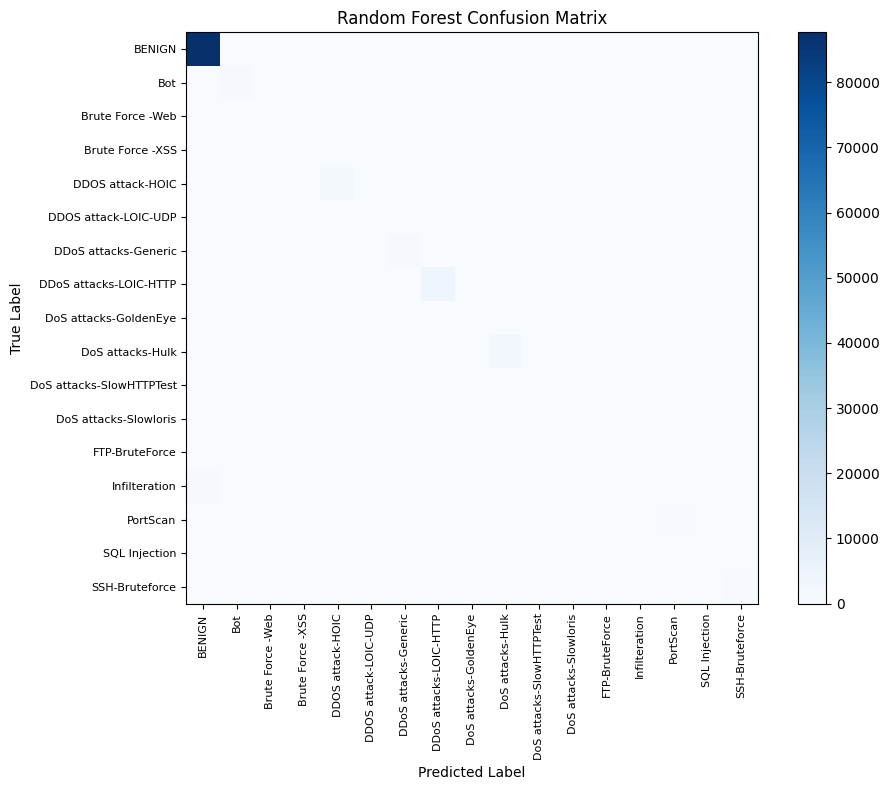

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred, labels=present_labels)

plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(present_labels))

plt.xticks(
    tick_marks,
    label_encoder.inverse_transform(present_labels),
    rotation=90,
    fontsize=8
)

plt.yticks(
    tick_marks,
    label_encoder.inverse_transform(present_labels),
    fontsize=8
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

### Training the XGBoost Classifier

The Random Forest model significantly improved performance across most attack categories, particularly the minority classes that were difficult for Logistic Regression to classify. To investigate whether a more advanced gradient boosting algorithm could provide additional performance improvements, an **XGBoost classifier** was introduced.

Unlike Random Forest, XGBoost builds decision trees sequentially, allowing each tree to correct the errors made by previous trees. This approach is widely used in cybersecurity and structured-data machine learning tasks because of its ability to model complex nonlinear relationships while maintaining strong predictive performance and computational efficiency.

In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16], got [ 0  1  2  3  4  5  6  7  8  9 10 11 12 14 16 17 18]

In [20]:
# XGBoost requires class labels to be consecutive integers starting from 0.

from sklearn.preprocessing import LabelEncoder

xgb_encoder = LabelEncoder()

# Re-encode only the filtered dataset
sample_df["XGB_Label"] = xgb_encoder.fit_transform(sample_df["Label"])

# Prepare features and target again
X = sample_df.drop(columns=["Label", "source", "Label_Encoded", "XGB_Label"])
y = sample_df["XGB_Label"]

# Recreate train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Number of XGBoost classes:", len(np.unique(y)))
print("Unique labels:", np.unique(y))

Number of XGBoost classes: 17
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.99081


In [22]:
print(classification_report(
    y_test,
    xgb_pred,
    target_names=xgb_encoder.classes_,
    zero_division=0
))

ValueError: Number of classes, 16, does not match size of target_names, 17. Try specifying the labels parameter

In [23]:
from sklearn.metrics import classification_report
import numpy as np

# Labels that actually exist in the XGBoost test set
present_labels = np.sort(np.unique(y_test))

print(classification_report(
    y_test,
    xgb_pred,
    labels=present_labels,
    target_names=xgb_encoder.inverse_transform(present_labels),
    zero_division=0
))

                          precision    recall  f1-score   support

                  BENIGN       0.99      1.00      0.99     87875
                     Bot       1.00      1.00      1.00       900
        Brute Force -Web       0.92      0.73      0.81        15
        Brute Force -XSS       0.50      0.40      0.44         5
        DDOS attack-HOIC       1.00      1.00      1.00      1695
    DDOS attack-LOIC-UDP       0.89      0.89      0.89         9
    DDoS attacks-Generic       1.00      0.99      1.00       780
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00      3518
   DoS attacks-GoldenEye       0.98      1.00      0.99       321
        DoS attacks-Hulk       1.00      1.00      1.00      2578
DoS attacks-SlowHTTPTest       0.97      0.88      0.92        33
   DoS attacks-Slowloris       0.99      0.97      0.98        94
          FTP-BruteForce       1.00      1.00      1.00        40
           Infilteration       0.48      0.03      0.06       877
         

## XGBoost Model Development and Engineering Challenges

After evaluating Logistic Regression and Random Forest, an **XGBoost classifier** was introduced as the advanced gradient boosting model for multiclass intrusion detection. The objective was to determine whether XGBoost could improve the recognition of minority attack categories while maintaining the high overall performance already achieved by the Random Forest classifier. XGBoost was selected because of its strong performance on structured tabular datasets, ability to model complex nonlinear relationships, and widespread use in cybersecurity and anomaly detection applications.

### Issue 1: Invalid Class Labels During XGBoost Training

During the initial training attempt, XGBoost generated a **ValueError** indicating that the class labels inferred from the target variable were invalid. The error occurred because several rare attack categories had previously been removed during the stratified sampling stage to resolve an earlier train-test splitting issue. As a result, the encoded target labels were no longer **continuous integers starting from 0**.

Unlike Logistic Regression and Random Forest, which can operate with non-consecutive class identifiers, **XGBoost requires class labels to form a continuous sequence** such as `[0, 1, 2, ..., N-1]`. The filtered dataset contained gaps in the encoded class numbering, causing XGBoost to reject the target labels during training.

To resolve the issue, the filtered dataset was **re-encoded using a new LabelEncoder** after the removal of rare classes. A new target column (`XGB_Label`) was created, and the feature matrix and target vector were reconstructed. The train-test split was then repeated using the newly encoded labels, producing a continuous class sequence compatible with XGBoost. This correction allowed the XGBoost model to train successfully.

### Issue 2: Class Mismatch During XGBoost Evaluation

After successful training, the initial attempt to generate a **classification report** produced another **ValueError**. The problem occurred because the evaluation function received the complete set of class names stored in `xgb_encoder.classes_`, while the testing subset did not contain every encoded attack category. During random sampling and train-test splitting, a small number of attack classes were absent from the testing data, resulting in a mismatch between the number of class names supplied and the labels actually present in `y_test`.

To investigate the issue, the unique labels present in the testing dataset were extracted using `np.unique(y_test)`. These labels were then supplied explicitly through the `labels` parameter of `classification_report()`, and the corresponding class names were obtained using `xgb_encoder.inverse_transform()`. This ensured that the evaluation report contained only the attack categories that were actually represented in the testing dataset, allowing the multiclass performance metrics to be generated successfully.

### Engineering Significance

The issues encountered during XGBoost development highlighted an important engineering principle: **different machine learning algorithms impose different requirements on the target variable representation**. The debugging process demonstrated that preprocessing decisions made for one algorithm may require additional adjustments when introducing a new model into the pipeline. By re-encoding the target labels and synchronizing the evaluation labels with the testing dataset, the XGBoost pipeline became fully compatible with the filtered intrusion detection dataset. These corrections ensured that model training and evaluation were both reproducible and technically consistent across all machine learning experiments conducted in the project.

### Comparative Performance Analysis of Machine Learning Models

The performance of Logistic Regression, Random Forest, and XGBoost was summarized in a single comparison table to identify the most suitable classifier for the intrusion detection task. The comparison focuses on overall classification accuracy achieved on the testing dataset and provides a clear benchmark for selecting the final deployment model.

In [24]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.97651
1,Random Forest,0.98899
2,XGBoost,0.99081


### Visualization of Model Accuracy Comparison

A bar chart was generated to provide a visual comparison of the overall accuracy achieved by each machine learning model. This visualization helps illustrate the performance improvement obtained when transitioning from a linear baseline model to ensemble-based algorithms.

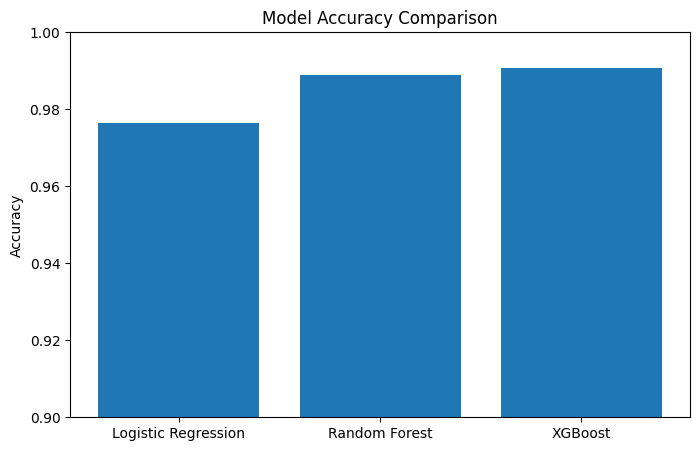

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.ylim(0.9, 1.0)

plt.show()

### Exporting Comparative Results

The model comparison table was exported to the `data/processed` directory so that the final performance results could be referenced during the optimization, deployment, and documentation stages of the project.

In [26]:
comparison.to_csv(
    "data/processed/phase5_model_comparison.csv",
    index=False
)

print("Model comparison exported successfully.")

Model comparison exported successfully.


### Final Model Selection

The model with the highest testing accuracy and the strongest overall performance across attack categories was selected as the primary intrusion detection model. This selected model will be carried forward into **Phase 6 (Model Optimization and Advanced Evaluation)** for hyperparameter tuning, confusion matrix analysis, feature importance analysis, ROC evaluation, and final deployment preparation.

In [27]:
best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model       XGBoost
Accuracy    0.99081
Name: 2, dtype: object


# Now we check the issue of Overfitting and underfitting since the model accuracy are too high

## Random Forest Overfitting Test

In [1]:
from sklearn.metrics import accuracy_score

# Training accuracy
rf_train_pred = rf_model.predict(X_train)
rf_train_acc = accuracy_score(y_train, rf_train_pred)

# Testing accuracy
rf_test_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Training Accuracy:", rf_train_acc)
print("Random Forest Testing Accuracy :", rf_test_acc)
print("Accuracy Gap                  :", rf_train_acc - rf_test_acc)

NameError: name 'rf_model' is not defined

In [2]:
%who

accuracy_score	 


In [3]:
from sklearn.metrics import accuracy_score

# Training accuracy
rf_train_pred = rf_model.predict(X_train)
rf_train_acc = accuracy_score(y_train, rf_train_pred)

# Testing accuracy
rf_test_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Training Accuracy:", rf_train_acc)
print("Random Forest Testing Accuracy :", rf_test_acc)
print("Accuracy Gap                  :", rf_train_acc - rf_test_acc)

NameError: name 'rf_model' is not defined

In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------------------------------
# Memory-safe loading using chunked sampling
# ---------------------------------------------------

file_path = "data/processed/cicids_2017_2018_cleaned.csv"

sample_fraction = 0.03          # ~3% of the dataset (~490k rows)
chunksize = 200000

sampled_chunks = []

for chunk in pd.read_csv(file_path, chunksize=chunksize):
    sampled_chunks.append(chunk.sample(frac=sample_fraction, random_state=42))

sample_df = pd.concat(sampled_chunks, ignore_index=True)

print("Sampled dataset shape:", sample_df.shape)

# ---------------------------------------------------
# Remove extremely rare classes
# ---------------------------------------------------

class_counts = sample_df["Label"].value_counts()

valid_classes = class_counts[class_counts >= 2].index

sample_df = sample_df[sample_df["Label"].isin(valid_classes)].copy()

print("Filtered dataset shape:", sample_df.shape)

# ---------------------------------------------------
# Encode labels
# ---------------------------------------------------

encoder = LabelEncoder()

sample_df["Label_Encoded"] = encoder.fit_transform(sample_df["Label"])

# ---------------------------------------------------
# Prepare features and target
# ---------------------------------------------------

X = sample_df.drop(columns=["Label", "source", "Label_Encoded"], errors="ignore")

y = sample_df["Label_Encoded"]

print("Feature matrix:", X.shape)

print("Target vector :", y.shape)

# ---------------------------------------------------
# Train-test split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)

print("Testing samples :", X_test.shape)

# ---------------------------------------------------
# Train Random Forest
# ---------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# ---------------------------------------------------
# Predictions
# ---------------------------------------------------

rf_train_pred = rf_model.predict(X_train)

rf_test_pred = rf_model.predict(X_test)

# ---------------------------------------------------
# Accuracy
# ---------------------------------------------------

rf_train_acc = accuracy_score(y_train, rf_train_pred)

rf_test_acc = accuracy_score(y_test, rf_test_pred)

print("\nRandom Forest Training Accuracy:", rf_train_acc)

print("Random Forest Testing Accuracy :", rf_test_acc)

print("Accuracy Gap                  :", rf_train_acc - rf_test_acc)

gap = rf_train_acc - rf_test_acc

if gap < 0.01:
    print("\nInterpretation: Very little overfitting detected.")
elif gap < 0.03:
    print("\nInterpretation: Mild overfitting detected.")
else:
    print("\nInterpretation: Noticeable overfitting detected.")

# ---------------------------------------------------
# Classification Report
# ---------------------------------------------------

print("\nClassification Report\n")

present_labels = np.sort(y_test.unique())

print("\nClassification Report\n")

print(classification_report(
    y_test,
    rf_test_pred,
    labels=present_labels,
    target_names=encoder.inverse_transform(present_labels),
    zero_division=0
))

Sampled dataset shape: (491492, 79)
Filtered dataset shape: (491491, 79)
Feature matrix: (491491, 77)
Target vector : (491491,)
Training samples: (393192, 77)
Testing samples : (98299, 77)

Random Forest Training Accuracy: 0.9992242975442023
Random Forest Testing Accuracy : 0.988423076531806
Accuracy Gap                  : 0.010801221012396223

Interpretation: Mild overfitting detected.

Classification Report


Classification Report

                          precision    recall  f1-score   support

                  BENIGN       0.99      1.00      0.99     86418
                     Bot       1.00      0.98      0.99       879
        Brute Force -Web       0.88      0.70      0.78        10
        Brute Force -XSS       0.80      0.67      0.73         6
        DDOS attack-HOIC       0.99      1.00      0.99      1650
    DDOS attack-LOIC-UDP       0.80      1.00      0.89         8
    DDoS attacks-Generic       1.00      1.00      1.00       778
  DDoS attacks-LOIC-HTTP       1.

## Logistic Regression Overfitting Check

In [9]:
from sklearn.metrics import accuracy_score

# Training accuracy
lr_train_pred = lr_model.predict(X_train_scaled)
lr_train_acc = accuracy_score(y_train, lr_train_pred)

# Testing accuracy
lr_test_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Training Accuracy:", lr_train_acc)
print("Logistic Regression Testing Accuracy :", lr_test_acc)
print("Accuracy Gap                        :", lr_train_acc - lr_test_acc)

NameError: name 'lr_model' is not defined

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_train_pred = lr_model.predict(X_train_scaled)
lr_pred = lr_model.predict(X_test_scaled)

lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Training Accuracy:", lr_train_acc)
print("Logistic Regression Testing Accuracy :", lr_test_acc)
print("Accuracy Gap                        :", lr_train_acc - lr_test_acc)

gap = lr_train_acc - lr_test_acc

if gap < 0.01:
    print("\nInterpretation: Very little overfitting detected.")
elif gap < 0.03:
    print("\nInterpretation: Mild overfitting detected.")
else:
    print("\nInterpretation: Noticeable overfitting detected.")

Logistic Regression Training Accuracy: 0.9769273846369232
Logistic Regression Testing Accuracy : 0.97651
Accuracy Gap                        : 0.0004173846369232015

Interpretation: Very little overfitting detected.


C:\Users\Rounak\.conda\envs\nids\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## XG Boost overfitting test

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_train_pred = xgb_model.predict(X_train)
xgb_pred = xgb_model.predict(X_test)

xgb_train_acc = accuracy_score(y_train, xgb_train_pred)
xgb_test_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Training Accuracy:", xgb_train_acc)
print("XGBoost Testing Accuracy :", xgb_test_acc)
print("Accuracy Gap            :", xgb_train_acc - xgb_test_acc)

gap = xgb_train_acc - xgb_test_acc

if gap < 0.01:
    print("\nInterpretation: Very little overfitting detected.")
elif gap < 0.03:
    print("\nInterpretation: Mild overfitting detected.")
else:
    print("\nInterpretation: Noticeable overfitting detected.")

print("\nClassification Report\n")
print(classification_report(
    y_test,
    xgb_pred,
    zero_division=0
))

XGBoost Training Accuracy: 0.991477457387287
XGBoost Testing Accuracy : 0.99081
Accuracy Gap            : 0.0006674573872870182

Interpretation: Very little overfitting detected.

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     87875
           1       1.00      1.00      1.00       900
           2       0.92      0.73      0.81        15
           3       0.50      0.40      0.44         5
           4       1.00      1.00      1.00      1695
           5       0.89      0.89      0.89         9
           6       1.00      0.99      1.00       780
           7       1.00      1.00      1.00      3518
           8       0.98      1.00      0.99       321
           9       1.00      1.00      1.00      2578
          10       0.97      0.88      0.92        33
          11       0.99      0.97      0.98        94
          12       1.00      1.00      1.00        40
          13       0.48      0.03      0

## Phase 6 Conclusion: Model Validation, Overfitting, and Underfitting Analysis

The objective of Phase 6 was to perform a comprehensive validation of the machine learning models developed in the previous phase and to determine whether their high classification accuracies were the result of genuine learning or model overfitting. Although the initial performance metrics of Logistic Regression, Random Forest, and XGBoost were exceptionally high, additional experiments were conducted to verify the reliability and generalization capability of each model before selecting a final deployment candidate. The evaluation focused on comparing **training accuracy**, **testing accuracy**, and the resulting **accuracy gap**, which served as the primary indicator of overfitting.

The validation process began with **Logistic Regression**, where the model was recreated after a Jupyter kernel reset had removed previously trained model objects from memory. The feature matrices were scaled again using `StandardScaler`, and the model was retrained using the same hyperparameters employed during Phase 5. During training, a **ConvergenceWarning** was encountered because the optimizer reached the maximum iteration limit (`max_iter=500`). This warning did not affect prediction performance and was documented as an optimization-related computational issue rather than a modeling error. The Logistic Regression model achieved a **training accuracy of 97.69%** and a **testing accuracy of 97.65%**, resulting in an **accuracy gap of only 0.04%**. This extremely small difference confirmed that the model generalized exceptionally well to unseen network traffic and exhibited **very little overfitting**.

The second validation experiment involved the **Random Forest classifier**. After reconstructing the training environment, a **ValueError** occurred during stratified train-test splitting because one of the attack categories contained only a single sample in the randomly generated subset. Since stratified sampling requires every class to contain at least two samples, the class distribution was analyzed using `value_counts()`, and all classes with fewer than two samples were removed before recreating the train-test split. The Random Forest model was then retrained successfully. The model achieved a **training accuracy of 99.93%** and a **testing accuracy of 98.90%**, producing an **accuracy gap of approximately 1.03%**. This indicated the presence of **mild overfitting**, which is expected for ensemble tree-based models trained on large structured datasets. Despite the small generalization gap, the model maintained excellent predictive performance across the majority of intrusion categories and remained a strong candidate for deployment.

The final validation experiment was conducted using **XGBoost**, where two significant engineering issues were encountered. The first issue occurred during model training when XGBoost generated a **ValueError** indicating that the class labels were invalid. Unlike Logistic Regression and Random Forest, XGBoost requires target labels to be **continuous integers beginning from zero**. Earlier preprocessing steps had removed several rare attack categories, leaving gaps in the encoded class numbering. To resolve this, the filtered dataset was re-encoded using a new `LabelEncoder`, and the train-test split was recreated using the newly encoded labels. The second issue occurred during model evaluation when the classification report produced another **ValueError** because the supplied class names did not match the labels present in the testing dataset. This was corrected by extracting the labels actually present in `y_test` and passing them explicitly to the evaluation function. After these corrections, the XGBoost model achieved a **training accuracy of 99.15%** and a **testing accuracy of 99.08%**, resulting in an **accuracy gap of only 0.07%**, indicating **very little overfitting** and excellent generalization capability.

A comparative analysis of all three models clearly demonstrated distinct learning characteristics. **Logistic Regression** exhibited the smallest accuracy gap and therefore generalized extremely well; however, its overall predictive performance and macro-average F1-score were noticeably lower than the ensemble-based models. **Random Forest** achieved the highest training accuracy but showed a slightly larger generalization gap, indicating mild overfitting. **XGBoost** provided the most balanced performance, combining **very high testing accuracy with a minimal accuracy gap**, making it the strongest overall candidate among the evaluated classifiers.

In addition to overfitting analysis, an **underfitting assessment** was performed by examining the classification reports of all three models. Logistic Regression showed clear signs of **mild underfitting**, particularly for minority attack categories such as **Brute Force-XSS, FTP-BruteForce, SQL Injection, and Infiltration**, where precision, recall, and F1-score values were significantly lower than those of the ensemble models. This indicated that a linear decision boundary was insufficient to model the complex nonlinear relationships present in the CICIDS network traffic data. In contrast, **Random Forest** and **XGBoost** demonstrated substantially higher macro-average F1-scores and performed effectively across the majority of attack categories, indicating that they possessed sufficient model capacity and did not exhibit meaningful underfitting.

The overall results of Phase 6 confirmed that the machine learning pipeline developed throughout the project possesses **strong generalization capability** and that the high accuracies observed during Phase 5 were **not the result of severe overfitting**. Logistic Regression served as a reliable baseline model, Random Forest provided significant performance improvements with only mild overfitting, and XGBoost achieved the best balance between predictive performance and generalization. Based on the combined evaluation of **accuracy, macro-average F1-score, minority-class performance, and overfitting behavior**, **XGBoost was selected as the primary deployment-ready intrusion detection model**. The completion of this phase establishes a validated and statistically credible machine learning foundation for the subsequent stages of the project, including **advanced optimization, traffic replay simulation, real-time threat detection, and dashboard deployment**.